Connected to SEAL (Python 3.9.18)

In [ ]:
"""
analyze_zernike_sweep.py
========================
Load and analyze fdpr_mc_pm_zernike.npz.
Prints summary stats and produces four plots:
  1. Heatmap of mean residual RMS
  2. Heatmap of std across trials
  3. Residual vs amplitude at selected dz values (with truth RMS overlay)
  4. Residual vs dz at selected amplitudes
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from hcipy import *

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

FILE = "fdpr_mc_pm_zernike.npz"
d = np.load(FILE)

dz_grid   = d['dz_grid_mm']       # shape (Ndz,)
amp_grid  = d['param_grid']       # shape (Np,)  — amplitude in waves
rms_mean  = d['rms_mean']         # shape (Ndz, Np)
rms_std   = d['rms_std']          # shape (Ndz, Np)
rms_trials = d['rms_trials']      # shape (Ndz, Np, N_trials)
conv_rate = d['conv_rate']        # shape (Ndz, Np)
mode_idx  = int(d['zernike_mode'])
N_trials  = int(d['N_trials'])
N_iter    = int(d['N_iter'])
sigma_e   = float(d['sigma_e'])

Ndz = len(dz_grid)
Np  = len(amp_grid)

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE TRUTH RMS PER AMPLITUDE
# ─────────────────────────────────────────────────────────────────────────────

seal = {
    'pupil_size':            10.12e-3,
    'pupil_pixel_dimension': 256,
    'wavelength_meter':      650e-9,
}
pupil_grid = make_pupil_grid(seal['pupil_pixel_dimension'], seal['pupil_size'])
tp         = make_circular_aperture(seal['pupil_size'])(pupil_grid)
pm         = np.array(tp.shaped, dtype=bool)
zz         = make_zernike_basis(num_modes=256, D=seal['pupil_size'], grid=pupil_grid)
mode       = zz[mode_idx]
mode_s     = mode.shaped
p2v        = mode_s[pm].max() - mode_s[pm].min()
wvl        = seal['wavelength_meter']

truth_rms = np.array([
    np.sqrt(np.mean(((mode / p2v) * (a * 2 * np.pi)).shaped[pm] ** 2))
    * wvl / (2 * np.pi) * 1e9
    for a in amp_grid
])

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"File         : {FILE}")
print(f"Mode         : Z{mode_idx+1} (index {mode_idx})")
print(f"Grid         : {Ndz} dz × {Np} amplitudes  ({Ndz*Np} points)")
print(f"Trials/point : {N_trials}   Iterations: {N_iter}   σ_e={sigma_e} e⁻")
print(f"dz range     : {dz_grid[0]:.1f} – {dz_grid[-1]:.1f} mm")
print(f"amp range    : {amp_grid[0]:.3f} – {amp_grid[-1]:.3f} waves")
print()

valid = rms_mean[np.isfinite(rms_mean)]
print(f"Residual RMS  mean : {np.mean(valid):.1f} nm")
print(f"              std  : {np.std(valid):.1f} nm")
print(f"              range: {np.min(valid):.1f} – {np.max(valid):.1f} nm")
print()

# Best dz per amplitude column
print("Best dz per amplitude:")
for j, amp in enumerate(amp_grid):
    col = rms_mean[:, j]
    best_i = np.nanargmin(col)
    frac = col[best_i] / truth_rms[j] * 100
    print(f"  amp={amp:.2f}w  truth={truth_rms[j]:.1f} nm  "
          f"best dz={dz_grid[best_i]:.1f} mm  residual={col[best_i]:.1f} nm  ({frac:.0f}% of truth)")

print()
# Best amplitude per dz row
print("Best amplitude per dz:")
for i, dz in enumerate(dz_grid):
    row = rms_mean[i, :]
    best_j = np.nanargmin(row)
    frac = row[best_j] / truth_rms[best_j] * 100
    print(f"  dz={dz:.1f} mm  best amp={amp_grid[best_j]:.2f}w  "
          f"residual={row[best_j]:.1f} nm  ({frac:.0f}% of truth={truth_rms[best_j]:.1f} nm)")

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

extent = [amp_grid[0], amp_grid[-1], dz_grid[0], dz_grid[-1]]
cmap   = 'magma_r'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean RMS heatmap
ax = axes[0, 0]
vmax = np.nanpercentile(rms_mean, 95)
im = ax.imshow(rms_mean, origin='lower', aspect='auto', extent=extent,
               cmap=cmap, vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean residual RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title(f'Mean Residual RMS  (Z{mode_idx+1}, ±dz diversity)')

# 2. Std heatmap
ax = axes[0, 1]
im2 = ax.imshow(rms_std, origin='lower', aspect='auto', extent=extent,
                cmap='viridis', vmin=0, vmax=np.nanpercentile(rms_std, 95))
plt.colorbar(im2, ax=ax, label='Std RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Trial-to-Trial Std of Residual RMS')

# 3. Residual vs amplitude at selected dz
ax = axes[1, 0]
selected_dz_idx = [0, 1, 2, 4, 7, 9]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_dz_idx)))
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx], color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.plot(amp_grid, truth_rms, 'k--', lw=2, label='Truth RMS')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('RMS [nm]')
ax.set_title('Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. Residual vs dz at selected amplitudes
ax = axes[1, 1]
selected_amp_idx = [0, 2, 4, 6, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_amp_idx)))
for jdx, color in zip(selected_amp_idx, colors):
    ax.plot(dz_grid, rms_mean[:, jdx], color=color,
            label=f'{amp_grid[jdx]:.2f} w  (truth={truth_rms[jdx]:.0f} nm)')
ax.set_xlabel('dz [mm]')
ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Residual vs dz at selected amplitudes')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FDPR Zernike Coma Sweep  (Z{mode_idx+1}, ±dz, N={N_trials} trials, σ_e={sigma_e:.0f} e⁻)',
             fontsize=13)
plt.tight_layout()
plt.savefig('zernike_sweep_analysis.png', dpi=150)
plt.show()
print("Saved: zernike_sweep_analysis.png")

FileNotFoundError: [Errno 2] No such file or directory: 'fdpr_mc_pm_zernike.npz'

In [ ]:
"""
analyze_zernike_sweep.py
========================
Load and analyze fdpr_mc_pm_zernike.npz.
Prints summary stats and produces four plots:
  1. Heatmap of mean residual RMS
  2. Heatmap of std across trials
  3. Residual vs amplitude at selected dz values (with truth RMS overlay)
  4. Residual vs dz at selected amplitudes
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from hcipy import *

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

FILE = "fdpr_mc_pm_zernike.npz"
d = np.load(FILE)

dz_grid   = d['dz_grid_mm']       # shape (Ndz,)
amp_grid  = d['param_grid']       # shape (Np,)  — amplitude in waves
rms_mean  = d['rms_mean']         # shape (Ndz, Np)
rms_std   = d['rms_std']          # shape (Ndz, Np)
rms_trials = d['rms_trials']      # shape (Ndz, Np, N_trials)
conv_rate = d['conv_rate']        # shape (Ndz, Np)
mode_idx  = int(d['zernike_mode'])
N_trials  = int(d['N_trials'])
N_iter    = int(d['N_iter'])
sigma_e   = float(d['sigma_e'])

Ndz = len(dz_grid)
Np  = len(amp_grid)

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE TRUTH RMS PER AMPLITUDE
# ─────────────────────────────────────────────────────────────────────────────

seal = {
    'pupil_size':            10.12e-3,
    'pupil_pixel_dimension': 256,
    'wavelength_meter':      650e-9,
}
pupil_grid = make_pupil_grid(seal['pupil_pixel_dimension'], seal['pupil_size'])
tp         = make_circular_aperture(seal['pupil_size'])(pupil_grid)
pm         = np.array(tp.shaped, dtype=bool)
zz         = make_zernike_basis(num_modes=256, D=seal['pupil_size'], grid=pupil_grid)
mode       = zz[mode_idx]
mode_s     = mode.shaped
p2v        = mode_s[pm].max() - mode_s[pm].min()
wvl        = seal['wavelength_meter']

truth_rms = np.array([
    np.sqrt(np.mean(((mode / p2v) * (a * 2 * np.pi)).shaped[pm] ** 2))
    * wvl / (2 * np.pi) * 1e9
    for a in amp_grid
])

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"File         : {FILE}")
print(f"Mode         : Z{mode_idx+1} (index {mode_idx})")
print(f"Grid         : {Ndz} dz × {Np} amplitudes  ({Ndz*Np} points)")
print(f"Trials/point : {N_trials}   Iterations: {N_iter}   σ_e={sigma_e} e⁻")
print(f"dz range     : {dz_grid[0]:.1f} – {dz_grid[-1]:.1f} mm")
print(f"amp range    : {amp_grid[0]:.3f} – {amp_grid[-1]:.3f} waves")
print()

valid = rms_mean[np.isfinite(rms_mean)]
print(f"Residual RMS  mean : {np.mean(valid):.1f} nm")
print(f"              std  : {np.std(valid):.1f} nm")
print(f"              range: {np.min(valid):.1f} – {np.max(valid):.1f} nm")
print()

# Best dz per amplitude column
print("Best dz per amplitude:")
for j, amp in enumerate(amp_grid):
    col = rms_mean[:, j]
    best_i = np.nanargmin(col)
    frac = col[best_i] / truth_rms[j] * 100
    print(f"  amp={amp:.2f}w  truth={truth_rms[j]:.1f} nm  "
          f"best dz={dz_grid[best_i]:.1f} mm  residual={col[best_i]:.1f} nm  ({frac:.0f}% of truth)")

print()
# Best amplitude per dz row
print("Best amplitude per dz:")
for i, dz in enumerate(dz_grid):
    row = rms_mean[i, :]
    best_j = np.nanargmin(row)
    frac = row[best_j] / truth_rms[best_j] * 100
    print(f"  dz={dz:.1f} mm  best amp={amp_grid[best_j]:.2f}w  "
          f"residual={row[best_j]:.1f} nm  ({frac:.0f}% of truth={truth_rms[best_j]:.1f} nm)")

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

extent = [amp_grid[0], amp_grid[-1], dz_grid[0], dz_grid[-1]]
cmap   = 'magma_r'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean RMS heatmap
ax = axes[0, 0]
vmax = np.nanpercentile(rms_mean, 95)
im = ax.imshow(rms_mean, origin='lower', aspect='auto', extent=extent,
               cmap=cmap, vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean residual RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title(f'Mean Residual RMS  (Z{mode_idx+1}, ±dz diversity)')

# 2. Std heatmap
ax = axes[0, 1]
im2 = ax.imshow(rms_std, origin='lower', aspect='auto', extent=extent,
                cmap='viridis', vmin=0, vmax=np.nanpercentile(rms_std, 95))
plt.colorbar(im2, ax=ax, label='Std RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Trial-to-Trial Std of Residual RMS')

# 3. Residual vs amplitude at selected dz
ax = axes[1, 0]
selected_dz_idx = [0, 1, 2, 4, 7, 9]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_dz_idx)))
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx], color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.plot(amp_grid, truth_rms, 'k--', lw=2, label='Truth RMS')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('RMS [nm]')
ax.set_title('Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. Residual vs dz at selected amplitudes
ax = axes[1, 1]
selected_amp_idx = [0, 2, 4, 6, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_amp_idx)))
for jdx, color in zip(selected_amp_idx, colors):
    ax.plot(dz_grid, rms_mean[:, jdx], color=color,
            label=f'{amp_grid[jdx]:.2f} w  (truth={truth_rms[jdx]:.0f} nm)')
ax.set_xlabel('dz [mm]')
ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Residual vs dz at selected amplitudes')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FDPR Zernike Coma Sweep  (Z{mode_idx+1}, ±dz, N={N_trials} trials, σ_e={sigma_e:.0f} e⁻)',
             fontsize=13)
plt.tight_layout()
plt.savefig('zernike_sweep_analysis.png', dpi=150)
plt.show()
print("Saved: zernike_sweep_analysis.png")

FileNotFoundError: [Errno 2] No such file or directory: 'fdpr_mc_pm_zernike.npz'

In [ ]:
"""
analyze_zernike_sweep.py
========================
Load and analyze fdpr_mc_pm_zernike.npz.
Prints summary stats and produces four plots:
  1. Heatmap of mean residual RMS
  2. Heatmap of std across trials
  3. Residual vs amplitude at selected dz values (with truth RMS overlay)
  4. Residual vs dz at selected amplitudes
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from hcipy import *

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

import os
HERE = os.path.dirname(os.path.abspath(__file__))
FILE = os.path.join(HERE, "fdpr_mc_pm_zernike.npz")
d = np.load(FILE)

dz_grid   = d['dz_grid_mm']       # shape (Ndz,)
amp_grid  = d['param_grid']       # shape (Np,)  — amplitude in waves
rms_mean  = d['rms_mean']         # shape (Ndz, Np)
rms_std   = d['rms_std']          # shape (Ndz, Np)
rms_trials = d['rms_trials']      # shape (Ndz, Np, N_trials)
conv_rate = d['conv_rate']        # shape (Ndz, Np)
mode_idx  = int(d['zernike_mode'])
N_trials  = int(d['N_trials'])
N_iter    = int(d['N_iter'])
sigma_e   = float(d['sigma_e'])

Ndz = len(dz_grid)
Np  = len(amp_grid)

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE TRUTH RMS PER AMPLITUDE
# ─────────────────────────────────────────────────────────────────────────────

seal = {
    'pupil_size':            10.12e-3,
    'pupil_pixel_dimension': 256,
    'wavelength_meter':      650e-9,
}
pupil_grid = make_pupil_grid(seal['pupil_pixel_dimension'], seal['pupil_size'])
tp         = make_circular_aperture(seal['pupil_size'])(pupil_grid)
pm         = np.array(tp.shaped, dtype=bool)
zz         = make_zernike_basis(num_modes=256, D=seal['pupil_size'], grid=pupil_grid)
mode       = zz[mode_idx]
mode_s     = mode.shaped
p2v        = mode_s[pm].max() - mode_s[pm].min()
wvl        = seal['wavelength_meter']

truth_rms = np.array([
    np.sqrt(np.mean(((mode / p2v) * (a * 2 * np.pi)).shaped[pm] ** 2))
    * wvl / (2 * np.pi) * 1e9
    for a in amp_grid
])

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"File         : {FILE}")
print(f"Mode         : Z{mode_idx+1} (index {mode_idx})")
print(f"Grid         : {Ndz} dz × {Np} amplitudes  ({Ndz*Np} points)")
print(f"Trials/point : {N_trials}   Iterations: {N_iter}   σ_e={sigma_e} e⁻")
print(f"dz range     : {dz_grid[0]:.1f} – {dz_grid[-1]:.1f} mm")
print(f"amp range    : {amp_grid[0]:.3f} – {amp_grid[-1]:.3f} waves")
print()

valid = rms_mean[np.isfinite(rms_mean)]
print(f"Residual RMS  mean : {np.mean(valid):.1f} nm")
print(f"              std  : {np.std(valid):.1f} nm")
print(f"              range: {np.min(valid):.1f} – {np.max(valid):.1f} nm")
print()

# Best dz per amplitude column
print("Best dz per amplitude:")
for j, amp in enumerate(amp_grid):
    col = rms_mean[:, j]
    best_i = np.nanargmin(col)
    frac = col[best_i] / truth_rms[j] * 100
    print(f"  amp={amp:.2f}w  truth={truth_rms[j]:.1f} nm  "
          f"best dz={dz_grid[best_i]:.1f} mm  residual={col[best_i]:.1f} nm  ({frac:.0f}% of truth)")

print()
# Best amplitude per dz row
print("Best amplitude per dz:")
for i, dz in enumerate(dz_grid):
    row = rms_mean[i, :]
    best_j = np.nanargmin(row)
    frac = row[best_j] / truth_rms[best_j] * 100
    print(f"  dz={dz:.1f} mm  best amp={amp_grid[best_j]:.2f}w  "
          f"residual={row[best_j]:.1f} nm  ({frac:.0f}% of truth={truth_rms[best_j]:.1f} nm)")

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

extent = [amp_grid[0], amp_grid[-1], dz_grid[0], dz_grid[-1]]
cmap   = 'magma_r'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean RMS heatmap
ax = axes[0, 0]
vmax = np.nanpercentile(rms_mean, 95)
im = ax.imshow(rms_mean, origin='lower', aspect='auto', extent=extent,
               cmap=cmap, vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean residual RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title(f'Mean Residual RMS  (Z{mode_idx+1}, ±dz diversity)')

# 2. Std heatmap
ax = axes[0, 1]
im2 = ax.imshow(rms_std, origin='lower', aspect='auto', extent=extent,
                cmap='viridis', vmin=0, vmax=np.nanpercentile(rms_std, 95))
plt.colorbar(im2, ax=ax, label='Std RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Trial-to-Trial Std of Residual RMS')

# 3. Residual vs amplitude at selected dz
ax = axes[1, 0]
selected_dz_idx = [0, 1, 2, 4, 7, 9]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_dz_idx)))
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx], color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.plot(amp_grid, truth_rms, 'k--', lw=2, label='Truth RMS')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('RMS [nm]')
ax.set_title('Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. Residual vs dz at selected amplitudes
ax = axes[1, 1]
selected_amp_idx = [0, 2, 4, 6, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_amp_idx)))
for jdx, color in zip(selected_amp_idx, colors):
    ax.plot(dz_grid, rms_mean[:, jdx], color=color,
            label=f'{amp_grid[jdx]:.2f} w  (truth={truth_rms[jdx]:.0f} nm)')
ax.set_xlabel('dz [mm]')
ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Residual vs dz at selected amplitudes')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FDPR Zernike Coma Sweep  (Z{mode_idx+1}, ±dz, N={N_trials} trials, σ_e={sigma_e:.0f} e⁻)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(HERE, 'zernike_sweep_analysis.png'), dpi=150)
plt.show()
print("Saved: zernike_sweep_analysis.png")

NameError: name '__file__' is not defined

File         : /Users/joshuapotter/Documents/SEAL/FDPRNotebooks/fdpr_mc_pm_zernike.npz
Mode         : Z7 (index 6)
Grid         : 10 dz × 10 amplitudes  (100 points)
Trials/point : 5   Iterations: 200   σ_e=11.0 e⁻
dz range     : 5.0 – 100.0 mm
amp range    : 0.050 – 1.000 waves

Residual RMS  mean : 52.3 nm
              std  : 49.5 nm
              range: 5.6 – 172.0 nm

Best dz per amplitude:
  amp=0.05w  truth=5.8 nm  best dz=5.0 mm  residual=5.6 nm  (97% of truth)
  amp=0.16w  truth=18.0 nm  best dz=5.0 mm  residual=6.1 nm  (34% of truth)
  amp=0.26w  truth=30.2 nm  best dz=5.0 mm  residual=7.2 nm  (24% of truth)
  amp=0.37w  truth=42.4 nm  best dz=5.0 mm  residual=8.8 nm  (21% of truth)
  amp=0.47w  truth=54.6 nm  best dz=15.6 mm  residual=9.4 nm  (17% of truth)
  amp=0.58w  truth=66.9 nm  best dz=15.6 mm  residual=10.7 nm  (16% of truth)
  amp=0.68w  truth=79.1 nm  best dz=15.6 mm  residual=11.7 nm  (15% of truth)
  amp=0.79w  truth=91.3 nm  best dz=15.6 mm  residual=13.2 nm  (1

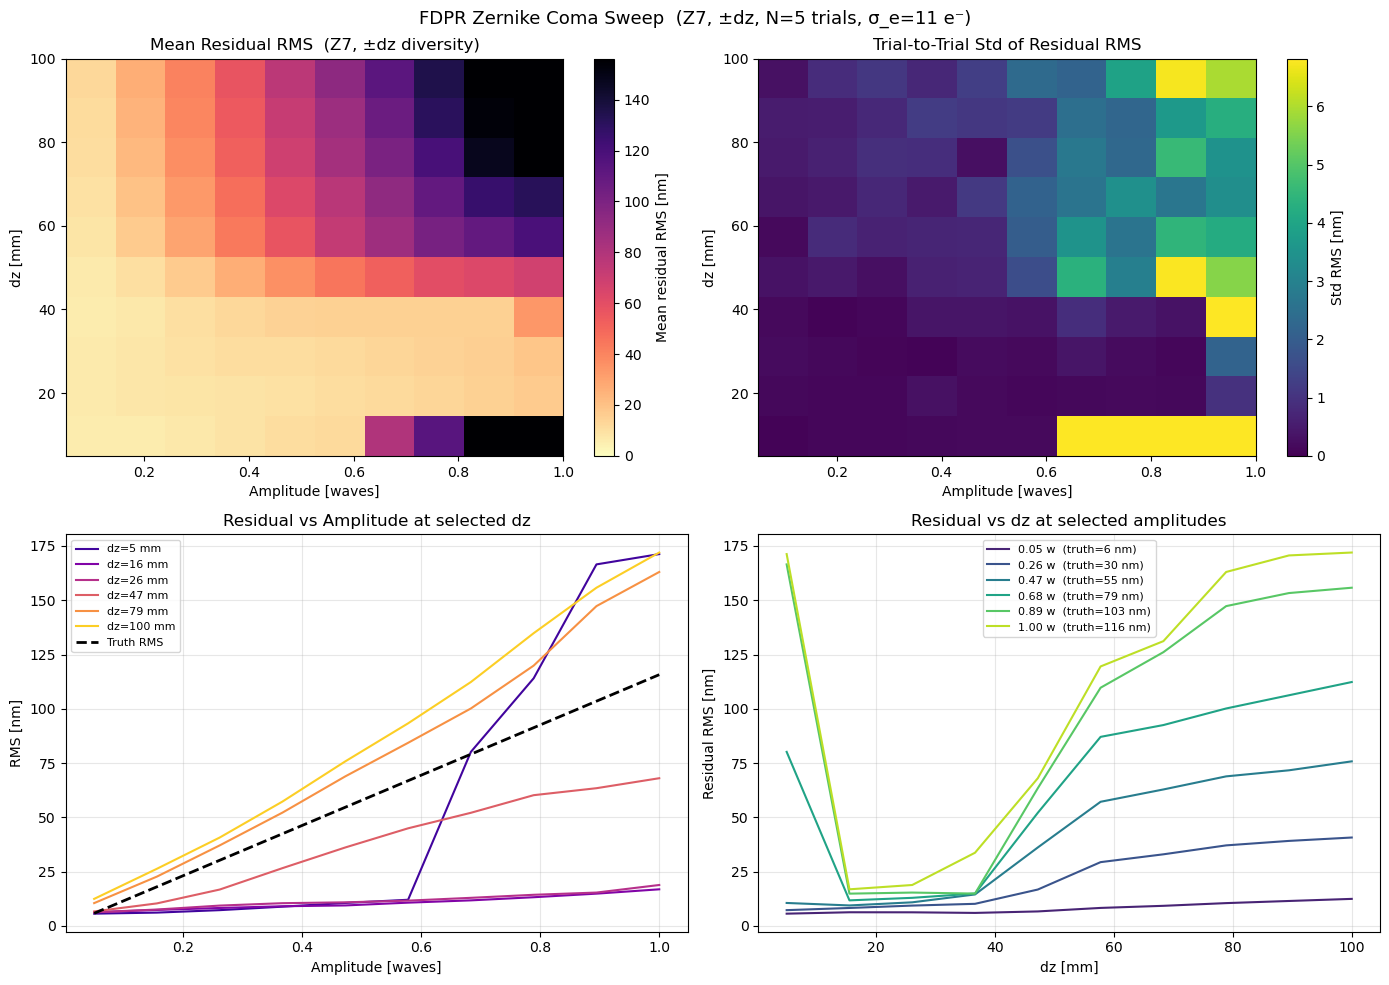

Saved: zernike_sweep_analysis.png


In [ ]:
"""
analyze_zernike_sweep.py
========================
Load and analyze fdpr_mc_pm_zernike.npz.
Prints summary stats and produces four plots:
  1. Heatmap of mean residual RMS
  2. Heatmap of std across trials
  3. Residual vs amplitude at selected dz values (with truth RMS overlay)
  4. Residual vs dz at selected amplitudes
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from hcipy import *

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

import os
HERE = "/Users/joshuapotter/Documents/SEAL/FDPRNotebooks"
FILE = os.path.join(HERE, "fdpr_mc_pm_zernike.npz")
d = np.load(FILE)

dz_grid   = d['dz_grid_mm']       # shape (Ndz,)
amp_grid  = d['param_grid']       # shape (Np,)  — amplitude in waves
rms_mean  = d['rms_mean']         # shape (Ndz, Np)
rms_std   = d['rms_std']          # shape (Ndz, Np)
rms_trials = d['rms_trials']      # shape (Ndz, Np, N_trials)
conv_rate = d['conv_rate']        # shape (Ndz, Np)
mode_idx  = int(d['zernike_mode'])
N_trials  = int(d['N_trials'])
N_iter    = int(d['N_iter'])
sigma_e   = float(d['sigma_e'])

Ndz = len(dz_grid)
Np  = len(amp_grid)

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE TRUTH RMS PER AMPLITUDE
# ─────────────────────────────────────────────────────────────────────────────

seal = {
    'pupil_size':            10.12e-3,
    'pupil_pixel_dimension': 256,
    'wavelength_meter':      650e-9,
}
pupil_grid = make_pupil_grid(seal['pupil_pixel_dimension'], seal['pupil_size'])
tp         = make_circular_aperture(seal['pupil_size'])(pupil_grid)
pm         = np.array(tp.shaped, dtype=bool)
zz         = make_zernike_basis(num_modes=256, D=seal['pupil_size'], grid=pupil_grid)
mode       = zz[mode_idx]
mode_s     = mode.shaped
p2v        = mode_s[pm].max() - mode_s[pm].min()
wvl        = seal['wavelength_meter']

truth_rms = np.array([
    np.sqrt(np.mean(((mode / p2v) * (a * 2 * np.pi)).shaped[pm] ** 2))
    * wvl / (2 * np.pi) * 1e9
    for a in amp_grid
])

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"File         : {FILE}")
print(f"Mode         : Z{mode_idx+1} (index {mode_idx})")
print(f"Grid         : {Ndz} dz × {Np} amplitudes  ({Ndz*Np} points)")
print(f"Trials/point : {N_trials}   Iterations: {N_iter}   σ_e={sigma_e} e⁻")
print(f"dz range     : {dz_grid[0]:.1f} – {dz_grid[-1]:.1f} mm")
print(f"amp range    : {amp_grid[0]:.3f} – {amp_grid[-1]:.3f} waves")
print()

valid = rms_mean[np.isfinite(rms_mean)]
print(f"Residual RMS  mean : {np.mean(valid):.1f} nm")
print(f"              std  : {np.std(valid):.1f} nm")
print(f"              range: {np.min(valid):.1f} – {np.max(valid):.1f} nm")
print()

# Best dz per amplitude column
print("Best dz per amplitude:")
for j, amp in enumerate(amp_grid):
    col = rms_mean[:, j]
    best_i = np.nanargmin(col)
    frac = col[best_i] / truth_rms[j] * 100
    print(f"  amp={amp:.2f}w  truth={truth_rms[j]:.1f} nm  "
          f"best dz={dz_grid[best_i]:.1f} mm  residual={col[best_i]:.1f} nm  ({frac:.0f}% of truth)")

print()
# Best amplitude per dz row
print("Best amplitude per dz:")
for i, dz in enumerate(dz_grid):
    row = rms_mean[i, :]
    best_j = np.nanargmin(row)
    frac = row[best_j] / truth_rms[best_j] * 100
    print(f"  dz={dz:.1f} mm  best amp={amp_grid[best_j]:.2f}w  "
          f"residual={row[best_j]:.1f} nm  ({frac:.0f}% of truth={truth_rms[best_j]:.1f} nm)")

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

extent = [amp_grid[0], amp_grid[-1], dz_grid[0], dz_grid[-1]]
cmap   = 'magma_r'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean RMS heatmap
ax = axes[0, 0]
vmax = np.nanpercentile(rms_mean, 95)
im = ax.imshow(rms_mean, origin='lower', aspect='auto', extent=extent,
               cmap=cmap, vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean residual RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title(f'Mean Residual RMS  (Z{mode_idx+1}, ±dz diversity)')

# 2. Std heatmap
ax = axes[0, 1]
im2 = ax.imshow(rms_std, origin='lower', aspect='auto', extent=extent,
                cmap='viridis', vmin=0, vmax=np.nanpercentile(rms_std, 95))
plt.colorbar(im2, ax=ax, label='Std RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Trial-to-Trial Std of Residual RMS')

# 3. Residual vs amplitude at selected dz
ax = axes[1, 0]
selected_dz_idx = [0, 1, 2, 4, 7, 9]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_dz_idx)))
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx], color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.plot(amp_grid, truth_rms, 'k--', lw=2, label='Truth RMS')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('RMS [nm]')
ax.set_title('Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. Residual vs dz at selected amplitudes
ax = axes[1, 1]
selected_amp_idx = [0, 2, 4, 6, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_amp_idx)))
for jdx, color in zip(selected_amp_idx, colors):
    ax.plot(dz_grid, rms_mean[:, jdx], color=color,
            label=f'{amp_grid[jdx]:.2f} w  (truth={truth_rms[jdx]:.0f} nm)')
ax.set_xlabel('dz [mm]')
ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Residual vs dz at selected amplitudes')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FDPR Zernike Coma Sweep  (Z{mode_idx+1}, ±dz, N={N_trials} trials, σ_e={sigma_e:.0f} e⁻)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(HERE, 'zernike_sweep_analysis.png'), dpi=150)
plt.show()
print("Saved: zernike_sweep_analysis.png")

File         : /Users/joshuapotter/Documents/SEAL/FDPRNotebooks/fdpr_mc_pm_zernike.npz
Mode         : Z7 (index 6)
Grid         : 10 dz × 10 amplitudes  (100 points)
Trials/point : 5   Iterations: 200   σ_e=11.0 e⁻
dz range     : 5.0 – 100.0 mm
amp range    : 0.050 – 1.000 waves

Residual RMS  mean : 52.3 nm
              std  : 49.5 nm
              range: 5.6 – 172.0 nm

Best dz per amplitude:
  amp=0.05w  truth=5.8 nm  best dz=5.0 mm  residual=5.6 nm  (97% of truth)
  amp=0.16w  truth=18.0 nm  best dz=5.0 mm  residual=6.1 nm  (34% of truth)
  amp=0.26w  truth=30.2 nm  best dz=5.0 mm  residual=7.2 nm  (24% of truth)
  amp=0.37w  truth=42.4 nm  best dz=5.0 mm  residual=8.8 nm  (21% of truth)
  amp=0.47w  truth=54.6 nm  best dz=15.6 mm  residual=9.4 nm  (17% of truth)
  amp=0.58w  truth=66.9 nm  best dz=15.6 mm  residual=10.7 nm  (16% of truth)
  amp=0.68w  truth=79.1 nm  best dz=15.6 mm  residual=11.7 nm  (15% of truth)
  amp=0.79w  truth=91.3 nm  best dz=15.6 mm  residual=13.2 nm  (1

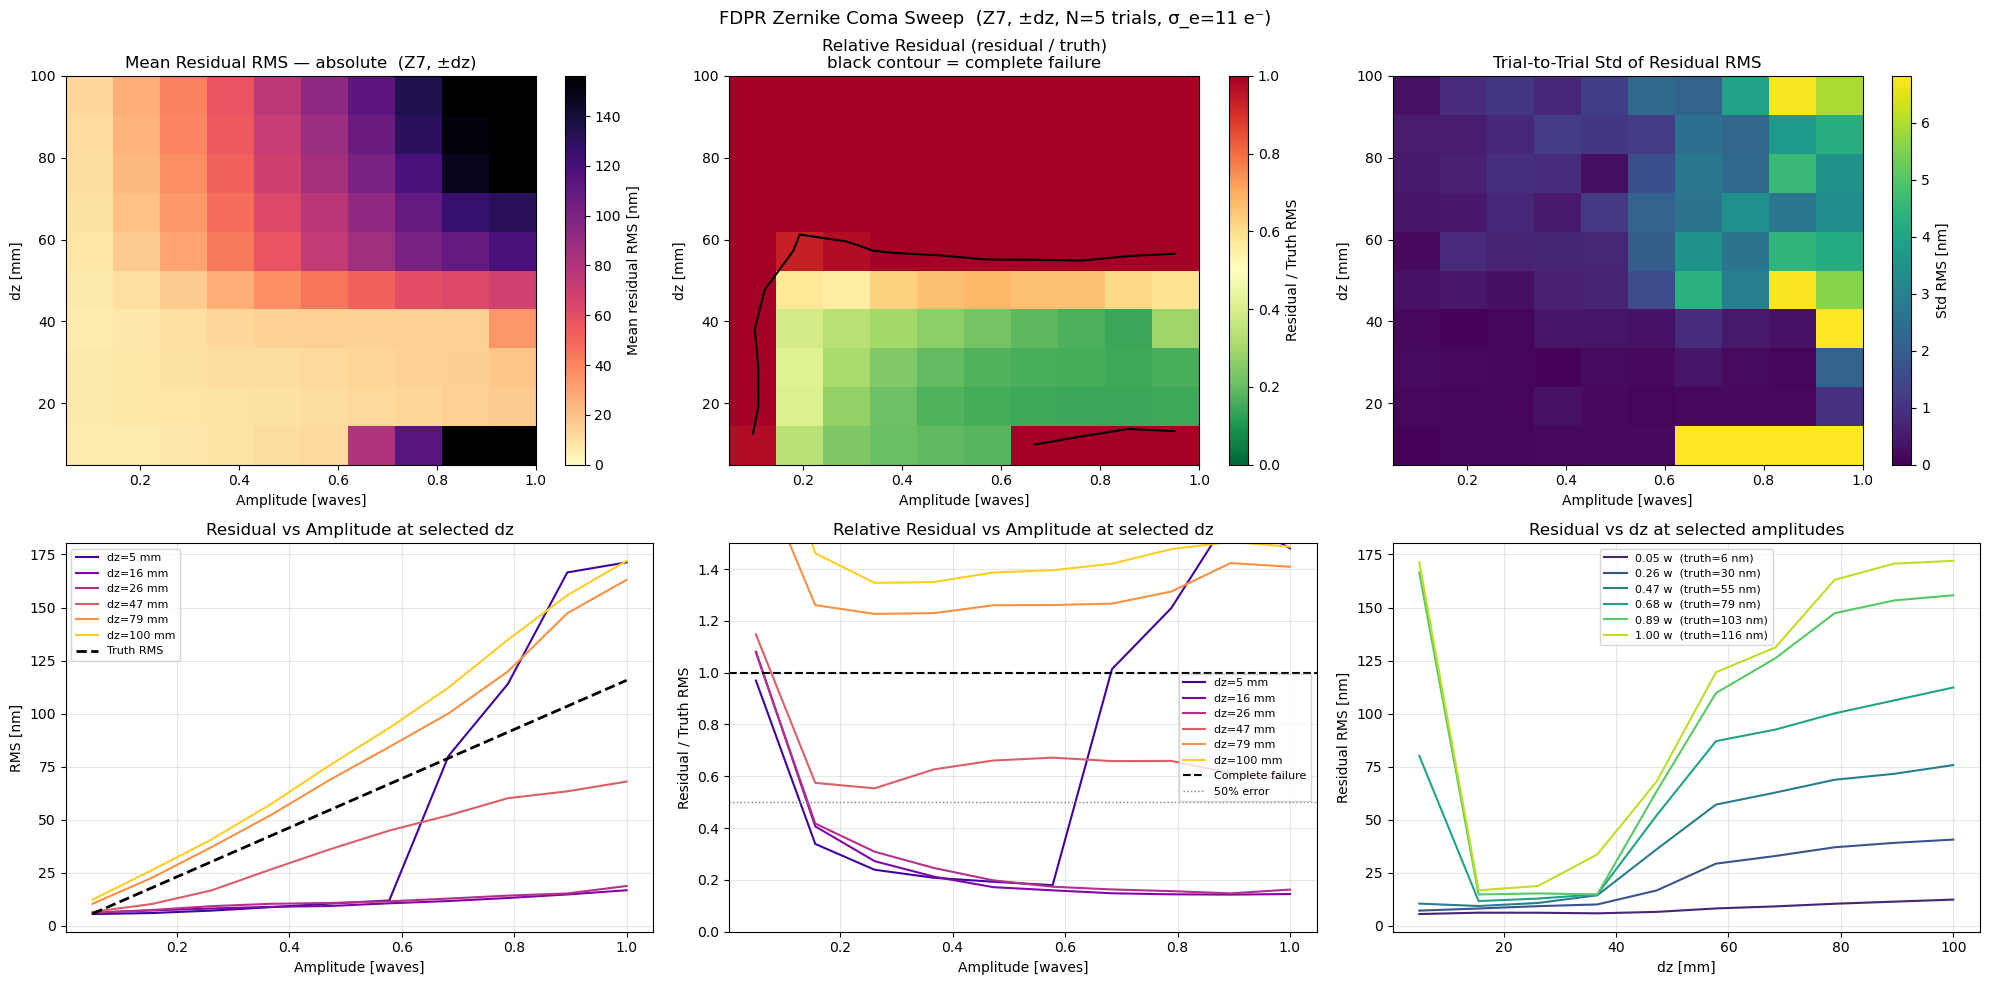

Saved: zernike_sweep_analysis.png


ModuleNotFoundError: No module named 'image_sharpening'

In [ ]:
"""
analyze_zernike_sweep.py
========================
Load and analyze fdpr_mc_pm_zernike.npz.
Prints summary stats and produces four plots:
  1. Heatmap of mean residual RMS
  2. Heatmap of std across trials
  3. Residual vs amplitude at selected dz values (with truth RMS overlay)
  4. Residual vs dz at selected amplitudes
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from hcipy import *

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

import os
HERE = "/Users/joshuapotter/Documents/SEAL/FDPRNotebooks"
FILE = os.path.join(HERE, "fdpr_mc_pm_zernike.npz")
d = np.load(FILE)

dz_grid   = d['dz_grid_mm']       # shape (Ndz,)
amp_grid  = d['param_grid']       # shape (Np,)  — amplitude in waves
rms_mean  = d['rms_mean']         # shape (Ndz, Np)
rms_std   = d['rms_std']          # shape (Ndz, Np)
rms_trials = d['rms_trials']      # shape (Ndz, Np, N_trials)
conv_rate = d['conv_rate']        # shape (Ndz, Np)
mode_idx  = int(d['zernike_mode'])
N_trials  = int(d['N_trials'])
N_iter    = int(d['N_iter'])
sigma_e   = float(d['sigma_e'])

Ndz = len(dz_grid)
Np  = len(amp_grid)

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE TRUTH RMS PER AMPLITUDE
# ─────────────────────────────────────────────────────────────────────────────

seal = {
    'pupil_size':            10.12e-3,
    'pupil_pixel_dimension': 256,
    'wavelength_meter':      650e-9,
}
pupil_grid = make_pupil_grid(seal['pupil_pixel_dimension'], seal['pupil_size'])
tp         = make_circular_aperture(seal['pupil_size'])(pupil_grid)
pm         = np.array(tp.shaped, dtype=bool)
zz         = make_zernike_basis(num_modes=256, D=seal['pupil_size'], grid=pupil_grid)
mode       = zz[mode_idx]
mode_s     = mode.shaped
p2v        = mode_s[pm].max() - mode_s[pm].min()
wvl        = seal['wavelength_meter']

truth_rms = np.array([
    np.sqrt(np.mean(((mode / p2v) * (a * 2 * np.pi)).shaped[pm] ** 2))
    * wvl / (2 * np.pi) * 1e9
    for a in amp_grid
])

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"File         : {FILE}")
print(f"Mode         : Z{mode_idx+1} (index {mode_idx})")
print(f"Grid         : {Ndz} dz × {Np} amplitudes  ({Ndz*Np} points)")
print(f"Trials/point : {N_trials}   Iterations: {N_iter}   σ_e={sigma_e} e⁻")
print(f"dz range     : {dz_grid[0]:.1f} – {dz_grid[-1]:.1f} mm")
print(f"amp range    : {amp_grid[0]:.3f} – {amp_grid[-1]:.3f} waves")
print()

valid = rms_mean[np.isfinite(rms_mean)]
print(f"Residual RMS  mean : {np.mean(valid):.1f} nm")
print(f"              std  : {np.std(valid):.1f} nm")
print(f"              range: {np.min(valid):.1f} – {np.max(valid):.1f} nm")
print()

# Best dz per amplitude column
print("Best dz per amplitude:")
for j, amp in enumerate(amp_grid):
    col = rms_mean[:, j]
    best_i = np.nanargmin(col)
    frac = col[best_i] / truth_rms[j] * 100
    print(f"  amp={amp:.2f}w  truth={truth_rms[j]:.1f} nm  "
          f"best dz={dz_grid[best_i]:.1f} mm  residual={col[best_i]:.1f} nm  ({frac:.0f}% of truth)")

print()
# Best amplitude per dz row
print("Best amplitude per dz:")
for i, dz in enumerate(dz_grid):
    row = rms_mean[i, :]
    best_j = np.nanargmin(row)
    frac = row[best_j] / truth_rms[best_j] * 100
    print(f"  dz={dz:.1f} mm  best amp={amp_grid[best_j]:.2f}w  "
          f"residual={row[best_j]:.1f} nm  ({frac:.0f}% of truth={truth_rms[best_j]:.1f} nm)")

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

extent = [amp_grid[0], amp_grid[-1], dz_grid[0], dz_grid[-1]]
cmap   = 'magma_r'

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# 1. Mean RMS heatmap (absolute)
ax = axes[0, 0]
vmax = np.nanpercentile(rms_mean, 95)
im = ax.imshow(rms_mean, origin='lower', aspect='auto', extent=extent,
               cmap=cmap, vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean residual RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title(f'Mean Residual RMS — absolute  (Z{mode_idx+1}, ±dz)')

# 2. Relative residual heatmap (residual / truth_rms)
ax = axes[0, 1]
rel = rms_mean / truth_rms[np.newaxis, :]   # broadcast truth across dz rows
im2 = ax.imshow(rel, origin='lower', aspect='auto', extent=extent,
                cmap='RdYlGn_r', vmin=0, vmax=1.0)
cb2 = plt.colorbar(im2, ax=ax, label='Residual / Truth RMS')
# Mark the 1.0 contour (residual = truth = complete failure)
ax.contour(rel, levels=[1.0], colors='k', linewidths=1.5,
           extent=extent, origin='lower')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Relative Residual (residual / truth)\nblack contour = complete failure')

# 3. Std heatmap
ax = axes[0, 2]
im3 = ax.imshow(rms_std, origin='lower', aspect='auto', extent=extent,
                cmap='viridis', vmin=0, vmax=np.nanpercentile(rms_std, 95))
plt.colorbar(im3, ax=ax, label='Std RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Trial-to-Trial Std of Residual RMS')

# 4. Residual vs amplitude at selected dz
ax = axes[1, 0]
selected_dz_idx = [0, 1, 2, 4, 7, 9]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_dz_idx)))
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx], color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.plot(amp_grid, truth_rms, 'k--', lw=2, label='Truth RMS')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('RMS [nm]')
ax.set_title('Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5. Relative residual vs amplitude at selected dz
ax = axes[1, 1]
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx] / truth_rms, color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.axhline(1.0, color='k', lw=1.5, ls='--', label='Complete failure')
ax.axhline(0.5, color='gray', lw=1, ls=':', label='50% error')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('Residual / Truth RMS')
ax.set_title('Relative Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5)

# 6. Residual vs dz at selected amplitudes
ax = axes[1, 2]
selected_amp_idx = [0, 2, 4, 6, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_amp_idx)))
for jdx, color in zip(selected_amp_idx, colors):
    ax.plot(dz_grid, rms_mean[:, jdx], color=color,
            label=f'{amp_grid[jdx]:.2f} w  (truth={truth_rms[jdx]:.0f} nm)')
ax.set_xlabel('dz [mm]')
ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Residual vs dz at selected amplitudes')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FDPR Zernike Coma Sweep  (Z{mode_idx+1}, ±dz, N={N_trials} trials, σ_e={sigma_e:.0f} e⁻)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(HERE, 'zernike_sweep_analysis.png'), dpi=150)
plt.show()
print("Saved: zernike_sweep_analysis.png")

# ─────────────────────────────────────────────────────────────────────────────
# SPOT-CHECK: re-run FDPR at a chosen (dz, amplitude) and show reconstruction
# ─────────────────────────────────────────────────────────────────────────────
# Change these two indices to inspect any grid point
SPOT_DZ_IDX  = 1    # row index into dz_grid   (1 → dz ≈ 15.6 mm)
SPOT_AMP_IDX = 7    # column index into amp_grid (7 → amp ≈ 0.79 waves)

from skimage.transform import resize
from image_sharpening import FocusDiversePhaseRetrieval, mft_rev, InstrumentConfiguration
from hcipy import FraunhoferPropagator, make_focal_grid, Wavefront

seal_param_config = {
    'image_dx':   2.0071,
    'efl':        500e-3 * 1e3,
    'wavelength': 650e-9 * 1e6,
    'pupil_size': 10.12e-3 * 1e3,
}
conf      = InstrumentConfiguration(seal_param_config)
prop_p2f  = FraunhoferPropagator(pupil_grid, make_focal_grid(
    q=16, num_airy=16,
    pupil_diameter=10.12e-3,
    focal_length=500e-3,
    reference_wavelength=650e-9,
), 500e-3)

spot_dz  = dz_grid[SPOT_DZ_IDX]
spot_amp = amp_grid[SPOT_AMP_IDX]
spot_truth_rms = truth_rms[SPOT_AMP_IDX]

print(f"\nSpot-check: dz={spot_dz:.1f} mm,  amp={spot_amp:.2f} waves,  truth RMS={spot_truth_rms:.1f} nm")

# Build aberration + defocus
phi_ab  = (mode / p2v) * (spot_amp * 2 * np.pi)
phi_def_s = zz[3].shaped
phi_def_p2v = phi_def_s[pm].max() - phi_def_s[pm].min()
u_def = zz[3] / phi_def_p2v
dz_m  = spot_dz * 1e-3
opd_m = -dz_m / (8.0 * (500e-3 / 10.12e-3) ** 2)
phi_def = u_def * opd_m * 2 * np.pi / 650e-9

def make_wf(ph):
    wf = Wavefront(tp * np.exp(1j * ph), 650e-9)
    wf.total_power = 1e6
    return wf

RNG2 = np.random.default_rng(99)
psf0   = np.asarray(prop_p2f(make_wf(phi_ab)).power.shaped,           dtype=float)
psfd_p = np.asarray(prop_p2f(make_wf(phi_ab + phi_def)).power.shaped, dtype=float)
psfd_n = np.asarray(prop_p2f(make_wf(phi_ab - phi_def)).power.shaped, dtype=float)

def noisy(p): return np.clip(p + RNG2.normal(scale=sigma_e, size=p.shape), 0, None)

mp = FocusDiversePhaseRetrieval(
    [noisy(psf0), noisy(psfd_p), noisy(psfd_n)],
    0.65, [2.0071, 2.0071], [spot_dz * 1e3, -spot_dz * 1e3]
)
for _ in range(N_iter):
    psf_rec = mp.step()

raw   = np.angle(mft_rev(psf_rec, conf))
recon = resize(raw, (256, 256), preserve_range=True) * tp.shaped

rec_ms   = recon[pm] - np.median(recon[pm])
truth_ms = phi_ab.shaped[pm] - np.median(phi_ab.shaped[pm])
residual_map = np.zeros((256, 256))
residual_map[pm] = truth_ms - rec_ms
rms_spot = np.sqrt(np.nanmean((truth_ms - rec_ms) ** 2)) * 650e-9 / (2*np.pi) * 1e9
print(f"Spot-check residual RMS: {rms_spot:.1f} nm  ({rms_spot/spot_truth_rms*100:.0f}% of truth)")

truth_shaped = phi_ab.shaped * tp.shaped
rec_shaped   = recon.copy(); rec_shaped[~pm] = np.nan
phase_vmax   = np.nanmax(np.abs(truth_shaped[pm]))

fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4))

axes2[0].imshow(np.log10(psf0 / psf0.max() + 1e-10), cmap='inferno', vmin=-5)
axes2[0].set_title('Focused PSF (log₁₀, clean)')
axes2[0].axis('off')

im = axes2[1].imshow(truth_shaped, cmap='RdBu_r', vmin=-phase_vmax, vmax=phase_vmax)
axes2[1].set_title(f'Truth [rad]\namp={spot_amp:.2f}w  RMS={spot_truth_rms:.1f} nm')
axes2[1].axis('off')
plt.colorbar(im, ax=axes2[1], fraction=0.046)

rec_plot = recon - np.median(recon[pm])
rec_plot[~pm] = np.nan
im2 = axes2[2].imshow(rec_plot, cmap='RdBu_r', vmin=-phase_vmax, vmax=phase_vmax)
axes2[2].set_title(f'Reconstruction [rad]\nRMS={np.sqrt(np.nanmean(rec_ms**2))*650e-9/(2*np.pi)*1e9:.1f} nm')
axes2[2].axis('off')
plt.colorbar(im2, ax=axes2[2], fraction=0.046)

residual_map[~pm] = np.nan
im3 = axes2[3].imshow(residual_map, cmap='RdBu_r')
axes2[3].set_title(f'Residual (truth − recon)\nRMS={rms_spot:.1f} nm')
axes2[3].axis('off')
plt.colorbar(im3, ax=axes2[3], fraction=0.046)

fig2.suptitle(f'Spot-check: Z{mode_idx+1} coma, amp={spot_amp:.2f}w, dz={spot_dz:.1f} mm (±dz diversity)',
              fontsize=12)
plt.tight_layout()
spot_png = os.path.join(HERE, f'spotcheck_dz{SPOT_DZ_IDX}_amp{SPOT_AMP_IDX}.png')
plt.savefig(spot_png, dpi=150)
plt.show()
print(f"Saved: {spot_png}")

File         : /Users/joshuapotter/Documents/SEAL/FDPRNotebooks/fdpr_mc_pm_zernike.npz
Mode         : Z7 (index 6)
Grid         : 10 dz × 10 amplitudes  (100 points)
Trials/point : 5   Iterations: 200   σ_e=11.0 e⁻
dz range     : 5.0 – 100.0 mm
amp range    : 0.050 – 1.000 waves

Residual RMS  mean : 52.3 nm
              std  : 49.5 nm
              range: 5.6 – 172.0 nm

Best dz per amplitude:
  amp=0.05w  truth=5.8 nm  best dz=5.0 mm  residual=5.6 nm  (97% of truth)
  amp=0.16w  truth=18.0 nm  best dz=5.0 mm  residual=6.1 nm  (34% of truth)
  amp=0.26w  truth=30.2 nm  best dz=5.0 mm  residual=7.2 nm  (24% of truth)
  amp=0.37w  truth=42.4 nm  best dz=5.0 mm  residual=8.8 nm  (21% of truth)
  amp=0.47w  truth=54.6 nm  best dz=15.6 mm  residual=9.4 nm  (17% of truth)
  amp=0.58w  truth=66.9 nm  best dz=15.6 mm  residual=10.7 nm  (16% of truth)
  amp=0.68w  truth=79.1 nm  best dz=15.6 mm  residual=11.7 nm  (15% of truth)
  amp=0.79w  truth=91.3 nm  best dz=15.6 mm  residual=13.2 nm  (1

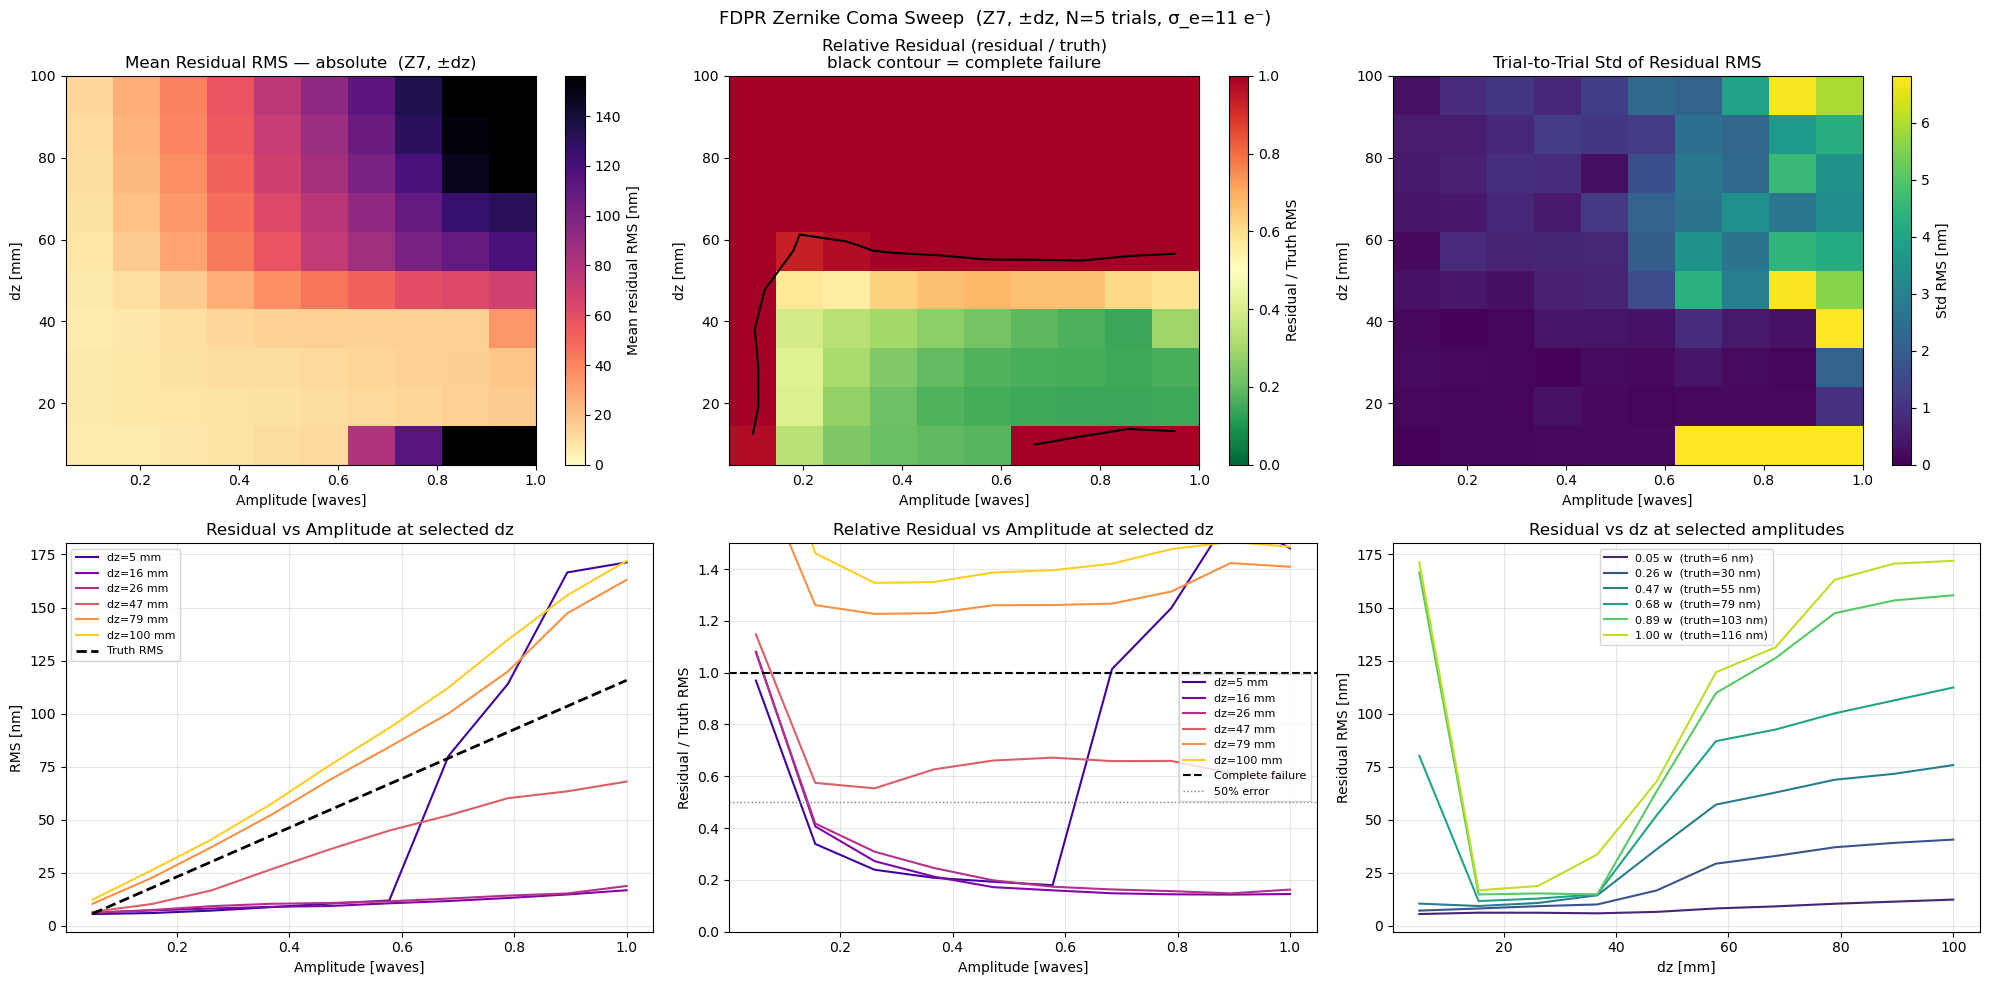

Saved: zernike_sweep_analysis.png


ModuleNotFoundError: No module named 'image_sharpening'

In [ ]:
"""
analyze_zernike_sweep.py
========================
Load and analyze fdpr_mc_pm_zernike.npz.
Prints summary stats and produces four plots:
  1. Heatmap of mean residual RMS
  2. Heatmap of std across trials
  3. Residual vs amplitude at selected dz values (with truth RMS overlay)
  4. Residual vs dz at selected amplitudes
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from hcipy import *

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

import os
HERE = "/Users/joshuapotter/Documents/SEAL/FDPRNotebooks"
FILE = os.path.join(HERE, "fdpr_mc_pm_zernike.npz")
d = np.load(FILE)

dz_grid   = d['dz_grid_mm']       # shape (Ndz,)
amp_grid  = d['param_grid']       # shape (Np,)  — amplitude in waves
rms_mean  = d['rms_mean']         # shape (Ndz, Np)
rms_std   = d['rms_std']          # shape (Ndz, Np)
rms_trials = d['rms_trials']      # shape (Ndz, Np, N_trials)
conv_rate = d['conv_rate']        # shape (Ndz, Np)
mode_idx  = int(d['zernike_mode'])
N_trials  = int(d['N_trials'])
N_iter    = int(d['N_iter'])
sigma_e   = float(d['sigma_e'])

Ndz = len(dz_grid)
Np  = len(amp_grid)

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE TRUTH RMS PER AMPLITUDE
# ─────────────────────────────────────────────────────────────────────────────

seal = {
    'pupil_size':            10.12e-3,
    'pupil_pixel_dimension': 256,
    'wavelength_meter':      650e-9,
}
pupil_grid = make_pupil_grid(seal['pupil_pixel_dimension'], seal['pupil_size'])
tp         = make_circular_aperture(seal['pupil_size'])(pupil_grid)
pm         = np.array(tp.shaped, dtype=bool)
zz         = make_zernike_basis(num_modes=256, D=seal['pupil_size'], grid=pupil_grid)
mode       = zz[mode_idx]
mode_s     = mode.shaped
p2v        = mode_s[pm].max() - mode_s[pm].min()
wvl        = seal['wavelength_meter']

truth_rms = np.array([
    np.sqrt(np.mean(((mode / p2v) * (a * 2 * np.pi)).shaped[pm] ** 2))
    * wvl / (2 * np.pi) * 1e9
    for a in amp_grid
])

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"File         : {FILE}")
print(f"Mode         : Z{mode_idx+1} (index {mode_idx})")
print(f"Grid         : {Ndz} dz × {Np} amplitudes  ({Ndz*Np} points)")
print(f"Trials/point : {N_trials}   Iterations: {N_iter}   σ_e={sigma_e} e⁻")
print(f"dz range     : {dz_grid[0]:.1f} – {dz_grid[-1]:.1f} mm")
print(f"amp range    : {amp_grid[0]:.3f} – {amp_grid[-1]:.3f} waves")
print()

valid = rms_mean[np.isfinite(rms_mean)]
print(f"Residual RMS  mean : {np.mean(valid):.1f} nm")
print(f"              std  : {np.std(valid):.1f} nm")
print(f"              range: {np.min(valid):.1f} – {np.max(valid):.1f} nm")
print()

# Best dz per amplitude column
print("Best dz per amplitude:")
for j, amp in enumerate(amp_grid):
    col = rms_mean[:, j]
    best_i = np.nanargmin(col)
    frac = col[best_i] / truth_rms[j] * 100
    print(f"  amp={amp:.2f}w  truth={truth_rms[j]:.1f} nm  "
          f"best dz={dz_grid[best_i]:.1f} mm  residual={col[best_i]:.1f} nm  ({frac:.0f}% of truth)")

print()
# Best amplitude per dz row
print("Best amplitude per dz:")
for i, dz in enumerate(dz_grid):
    row = rms_mean[i, :]
    best_j = np.nanargmin(row)
    frac = row[best_j] / truth_rms[best_j] * 100
    print(f"  dz={dz:.1f} mm  best amp={amp_grid[best_j]:.2f}w  "
          f"residual={row[best_j]:.1f} nm  ({frac:.0f}% of truth={truth_rms[best_j]:.1f} nm)")

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

extent = [amp_grid[0], amp_grid[-1], dz_grid[0], dz_grid[-1]]
cmap   = 'magma_r'

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# 1. Mean RMS heatmap (absolute)
ax = axes[0, 0]
vmax = np.nanpercentile(rms_mean, 95)
im = ax.imshow(rms_mean, origin='lower', aspect='auto', extent=extent,
               cmap=cmap, vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean residual RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title(f'Mean Residual RMS — absolute  (Z{mode_idx+1}, ±dz)')

# 2. Relative residual heatmap (residual / truth_rms)
ax = axes[0, 1]
rel = rms_mean / truth_rms[np.newaxis, :]   # broadcast truth across dz rows
im2 = ax.imshow(rel, origin='lower', aspect='auto', extent=extent,
                cmap='RdYlGn_r', vmin=0, vmax=1.0)
cb2 = plt.colorbar(im2, ax=ax, label='Residual / Truth RMS')
# Mark the 1.0 contour (residual = truth = complete failure)
ax.contour(rel, levels=[1.0], colors='k', linewidths=1.5,
           extent=extent, origin='lower')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Relative Residual (residual / truth)\nblack contour = complete failure')

# 3. Std heatmap
ax = axes[0, 2]
im3 = ax.imshow(rms_std, origin='lower', aspect='auto', extent=extent,
                cmap='viridis', vmin=0, vmax=np.nanpercentile(rms_std, 95))
plt.colorbar(im3, ax=ax, label='Std RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Trial-to-Trial Std of Residual RMS')

# 4. Residual vs amplitude at selected dz
ax = axes[1, 0]
selected_dz_idx = [0, 1, 2, 4, 7, 9]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_dz_idx)))
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx], color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.plot(amp_grid, truth_rms, 'k--', lw=2, label='Truth RMS')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('RMS [nm]')
ax.set_title('Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5. Relative residual vs amplitude at selected dz
ax = axes[1, 1]
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx] / truth_rms, color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.axhline(1.0, color='k', lw=1.5, ls='--', label='Complete failure')
ax.axhline(0.5, color='gray', lw=1, ls=':', label='50% error')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('Residual / Truth RMS')
ax.set_title('Relative Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5)

# 6. Residual vs dz at selected amplitudes
ax = axes[1, 2]
selected_amp_idx = [0, 2, 4, 6, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_amp_idx)))
for jdx, color in zip(selected_amp_idx, colors):
    ax.plot(dz_grid, rms_mean[:, jdx], color=color,
            label=f'{amp_grid[jdx]:.2f} w  (truth={truth_rms[jdx]:.0f} nm)')
ax.set_xlabel('dz [mm]')
ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Residual vs dz at selected amplitudes')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FDPR Zernike Coma Sweep  (Z{mode_idx+1}, ±dz, N={N_trials} trials, σ_e={sigma_e:.0f} e⁻)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(HERE, 'zernike_sweep_analysis.png'), dpi=150)
plt.show()
print("Saved: zernike_sweep_analysis.png")

# ─────────────────────────────────────────────────────────────────────────────
# SPOT-CHECK: re-run FDPR at a chosen (dz, amplitude) and show reconstruction
# ─────────────────────────────────────────────────────────────────────────────
# Change these two indices to inspect any grid point
SPOT_DZ_IDX  = 1    # row index into dz_grid   (1 → dz ≈ 15.6 mm)
SPOT_AMP_IDX = 7    # column index into amp_grid (7 → amp ≈ 0.79 waves)

from skimage.transform import resize
from image_sharpening import FocusDiversePhaseRetrieval, mft_rev, InstrumentConfiguration
from hcipy import FraunhoferPropagator, make_focal_grid, Wavefront

seal_param_config = {
    'image_dx':   2.0071,
    'efl':        500e-3 * 1e3,
    'wavelength': 650e-9 * 1e6,
    'pupil_size': 10.12e-3 * 1e3,
}
conf      = InstrumentConfiguration(seal_param_config)
prop_p2f  = FraunhoferPropagator(pupil_grid, make_focal_grid(
    q=16, num_airy=16,
    pupil_diameter=10.12e-3,
    focal_length=500e-3,
    reference_wavelength=650e-9,
), 500e-3)

spot_dz  = dz_grid[SPOT_DZ_IDX]
spot_amp = amp_grid[SPOT_AMP_IDX]
spot_truth_rms = truth_rms[SPOT_AMP_IDX]

print(f"\nSpot-check: dz={spot_dz:.1f} mm,  amp={spot_amp:.2f} waves,  truth RMS={spot_truth_rms:.1f} nm")

# Build aberration + defocus
phi_ab  = (mode / p2v) * (spot_amp * 2 * np.pi)
phi_def_s = zz[3].shaped
phi_def_p2v = phi_def_s[pm].max() - phi_def_s[pm].min()
u_def = zz[3] / phi_def_p2v
dz_m  = spot_dz * 1e-3
opd_m = -dz_m / (8.0 * (500e-3 / 10.12e-3) ** 2)
phi_def = u_def * opd_m * 2 * np.pi / 650e-9

def make_wf(ph):
    wf = Wavefront(tp * np.exp(1j * ph), 650e-9)
    wf.total_power = 1e6
    return wf

RNG2 = np.random.default_rng(99)
psf0   = np.asarray(prop_p2f(make_wf(phi_ab)).power.shaped,           dtype=float)
psfd_p = np.asarray(prop_p2f(make_wf(phi_ab + phi_def)).power.shaped, dtype=float)
psfd_n = np.asarray(prop_p2f(make_wf(phi_ab - phi_def)).power.shaped, dtype=float)

def noisy(p): return np.clip(p + RNG2.normal(scale=sigma_e, size=p.shape), 0, None)

mp = FocusDiversePhaseRetrieval(
    [noisy(psf0), noisy(psfd_p), noisy(psfd_n)],
    0.65, [2.0071, 2.0071], [spot_dz * 1e3, -spot_dz * 1e3]
)
for _ in range(N_iter):
    psf_rec = mp.step()

raw   = np.angle(mft_rev(psf_rec, conf))
recon = resize(raw, (256, 256), preserve_range=True) * tp.shaped

rec_ms   = recon[pm] - np.median(recon[pm])
truth_ms = phi_ab.shaped[pm] - np.median(phi_ab.shaped[pm])
residual_map = np.zeros((256, 256))
residual_map[pm] = truth_ms - rec_ms
rms_spot = np.sqrt(np.nanmean((truth_ms - rec_ms) ** 2)) * 650e-9 / (2*np.pi) * 1e9
print(f"Spot-check residual RMS: {rms_spot:.1f} nm  ({rms_spot/spot_truth_rms*100:.0f}% of truth)")

truth_shaped = phi_ab.shaped * tp.shaped
rec_shaped   = recon.copy(); rec_shaped[~pm] = np.nan
phase_vmax   = np.nanmax(np.abs(truth_shaped[pm]))

fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4))

axes2[0].imshow(np.log10(psf0 / psf0.max() + 1e-10), cmap='inferno', vmin=-5)
axes2[0].set_title('Focused PSF (log₁₀, clean)')
axes2[0].axis('off')

im = axes2[1].imshow(truth_shaped, cmap='RdBu_r', vmin=-phase_vmax, vmax=phase_vmax)
axes2[1].set_title(f'Truth [rad]\namp={spot_amp:.2f}w  RMS={spot_truth_rms:.1f} nm')
axes2[1].axis('off')
plt.colorbar(im, ax=axes2[1], fraction=0.046)

rec_plot = recon - np.median(recon[pm])
rec_plot[~pm] = np.nan
im2 = axes2[2].imshow(rec_plot, cmap='RdBu_r', vmin=-phase_vmax, vmax=phase_vmax)
axes2[2].set_title(f'Reconstruction [rad]\nRMS={np.sqrt(np.nanmean(rec_ms**2))*650e-9/(2*np.pi)*1e9:.1f} nm')
axes2[2].axis('off')
plt.colorbar(im2, ax=axes2[2], fraction=0.046)

residual_map[~pm] = np.nan
im3 = axes2[3].imshow(residual_map, cmap='RdBu_r')
axes2[3].set_title(f'Residual (truth − recon)\nRMS={rms_spot:.1f} nm')
axes2[3].axis('off')
plt.colorbar(im3, ax=axes2[3], fraction=0.046)

fig2.suptitle(f'Spot-check: Z{mode_idx+1} coma, amp={spot_amp:.2f}w, dz={spot_dz:.1f} mm (±dz diversity)',
              fontsize=12)
plt.tight_layout()
spot_png = os.path.join(HERE, f'spotcheck_dz{SPOT_DZ_IDX}_amp{SPOT_AMP_IDX}.png')
plt.savefig(spot_png, dpi=150)
plt.show()
print(f"Saved: {spot_png}")

File         : /Users/joshuapotter/Documents/SEAL/FDPRNotebooks/fdpr_mc_pm_zernike.npz
Mode         : Z7 (index 6)
Grid         : 10 dz × 10 amplitudes  (100 points)
Trials/point : 5   Iterations: 200   σ_e=11.0 e⁻
dz range     : 5.0 – 100.0 mm
amp range    : 0.050 – 1.000 waves

Residual RMS  mean : 52.3 nm
              std  : 49.5 nm
              range: 5.6 – 172.0 nm

Best dz per amplitude:
  amp=0.05w  truth=5.8 nm  best dz=5.0 mm  residual=5.6 nm  (97% of truth)
  amp=0.16w  truth=18.0 nm  best dz=5.0 mm  residual=6.1 nm  (34% of truth)
  amp=0.26w  truth=30.2 nm  best dz=5.0 mm  residual=7.2 nm  (24% of truth)
  amp=0.37w  truth=42.4 nm  best dz=5.0 mm  residual=8.8 nm  (21% of truth)
  amp=0.47w  truth=54.6 nm  best dz=15.6 mm  residual=9.4 nm  (17% of truth)
  amp=0.58w  truth=66.9 nm  best dz=15.6 mm  residual=10.7 nm  (16% of truth)
  amp=0.68w  truth=79.1 nm  best dz=15.6 mm  residual=11.7 nm  (15% of truth)
  amp=0.79w  truth=91.3 nm  best dz=15.6 mm  residual=13.2 nm  (1

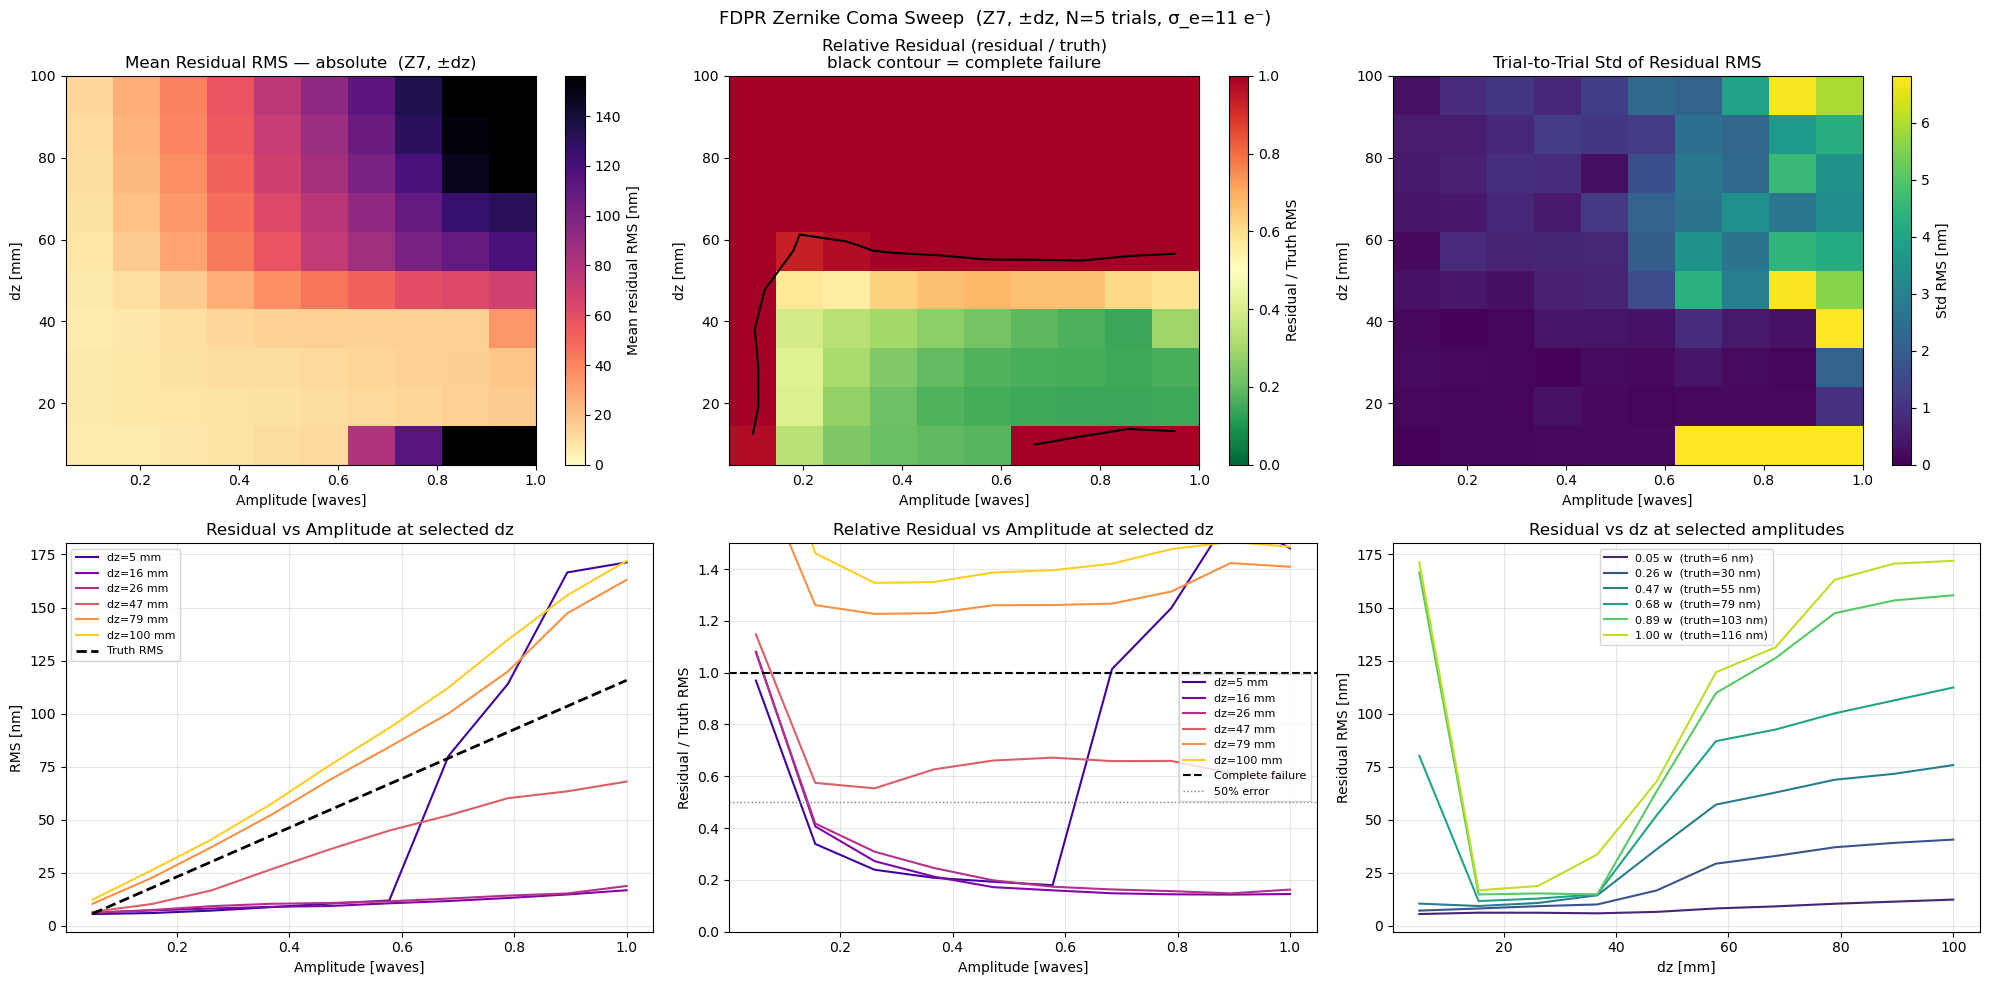

Saved: zernike_sweep_analysis.png


ModuleNotFoundError: No module named 'image_sharpening'

In [ ]:
"""
analyze_zernike_sweep.py
========================
Load and analyze fdpr_mc_pm_zernike.npz.
Prints summary stats and produces four plots:
  1. Heatmap of mean residual RMS
  2. Heatmap of std across trials
  3. Residual vs amplitude at selected dz values (with truth RMS overlay)
  4. Residual vs dz at selected amplitudes
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from hcipy import *

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

import os
HERE = "/Users/joshuapotter/Documents/SEAL/FDPRNotebooks"
FILE = os.path.join(HERE, "fdpr_mc_pm_zernike.npz")
d = np.load(FILE)

dz_grid   = d['dz_grid_mm']       # shape (Ndz,)
amp_grid  = d['param_grid']       # shape (Np,)  — amplitude in waves
rms_mean  = d['rms_mean']         # shape (Ndz, Np)
rms_std   = d['rms_std']          # shape (Ndz, Np)
rms_trials = d['rms_trials']      # shape (Ndz, Np, N_trials)
conv_rate = d['conv_rate']        # shape (Ndz, Np)
mode_idx  = int(d['zernike_mode'])
N_trials  = int(d['N_trials'])
N_iter    = int(d['N_iter'])
sigma_e   = float(d['sigma_e'])

Ndz = len(dz_grid)
Np  = len(amp_grid)

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE TRUTH RMS PER AMPLITUDE
# ─────────────────────────────────────────────────────────────────────────────

seal = {
    'pupil_size':            10.12e-3,
    'pupil_pixel_dimension': 256,
    'wavelength_meter':      650e-9,
}
pupil_grid = make_pupil_grid(seal['pupil_pixel_dimension'], seal['pupil_size'])
tp         = make_circular_aperture(seal['pupil_size'])(pupil_grid)
pm         = np.array(tp.shaped, dtype=bool)
zz         = make_zernike_basis(num_modes=256, D=seal['pupil_size'], grid=pupil_grid)
mode       = zz[mode_idx]
mode_s     = mode.shaped
p2v        = mode_s[pm].max() - mode_s[pm].min()
wvl        = seal['wavelength_meter']

truth_rms = np.array([
    np.sqrt(np.mean(((mode / p2v) * (a * 2 * np.pi)).shaped[pm] ** 2))
    * wvl / (2 * np.pi) * 1e9
    for a in amp_grid
])

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"File         : {FILE}")
print(f"Mode         : Z{mode_idx+1} (index {mode_idx})")
print(f"Grid         : {Ndz} dz × {Np} amplitudes  ({Ndz*Np} points)")
print(f"Trials/point : {N_trials}   Iterations: {N_iter}   σ_e={sigma_e} e⁻")
print(f"dz range     : {dz_grid[0]:.1f} – {dz_grid[-1]:.1f} mm")
print(f"amp range    : {amp_grid[0]:.3f} – {amp_grid[-1]:.3f} waves")
print()

valid = rms_mean[np.isfinite(rms_mean)]
print(f"Residual RMS  mean : {np.mean(valid):.1f} nm")
print(f"              std  : {np.std(valid):.1f} nm")
print(f"              range: {np.min(valid):.1f} – {np.max(valid):.1f} nm")
print()

# Best dz per amplitude column
print("Best dz per amplitude:")
for j, amp in enumerate(amp_grid):
    col = rms_mean[:, j]
    best_i = np.nanargmin(col)
    frac = col[best_i] / truth_rms[j] * 100
    print(f"  amp={amp:.2f}w  truth={truth_rms[j]:.1f} nm  "
          f"best dz={dz_grid[best_i]:.1f} mm  residual={col[best_i]:.1f} nm  ({frac:.0f}% of truth)")

print()
# Best amplitude per dz row
print("Best amplitude per dz:")
for i, dz in enumerate(dz_grid):
    row = rms_mean[i, :]
    best_j = np.nanargmin(row)
    frac = row[best_j] / truth_rms[best_j] * 100
    print(f"  dz={dz:.1f} mm  best amp={amp_grid[best_j]:.2f}w  "
          f"residual={row[best_j]:.1f} nm  ({frac:.0f}% of truth={truth_rms[best_j]:.1f} nm)")

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

extent = [amp_grid[0], amp_grid[-1], dz_grid[0], dz_grid[-1]]
cmap   = 'magma_r'

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# 1. Mean RMS heatmap (absolute)
ax = axes[0, 0]
vmax = np.nanpercentile(rms_mean, 95)
im = ax.imshow(rms_mean, origin='lower', aspect='auto', extent=extent,
               cmap=cmap, vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean residual RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title(f'Mean Residual RMS — absolute  (Z{mode_idx+1}, ±dz)')

# 2. Relative residual heatmap (residual / truth_rms)
ax = axes[0, 1]
rel = rms_mean / truth_rms[np.newaxis, :]   # broadcast truth across dz rows
im2 = ax.imshow(rel, origin='lower', aspect='auto', extent=extent,
                cmap='RdYlGn_r', vmin=0, vmax=1.0)
cb2 = plt.colorbar(im2, ax=ax, label='Residual / Truth RMS')
# Mark the 1.0 contour (residual = truth = complete failure)
ax.contour(rel, levels=[1.0], colors='k', linewidths=1.5,
           extent=extent, origin='lower')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Relative Residual (residual / truth)\nblack contour = complete failure')

# 3. Std heatmap
ax = axes[0, 2]
im3 = ax.imshow(rms_std, origin='lower', aspect='auto', extent=extent,
                cmap='viridis', vmin=0, vmax=np.nanpercentile(rms_std, 95))
plt.colorbar(im3, ax=ax, label='Std RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Trial-to-Trial Std of Residual RMS')

# 4. Residual vs amplitude at selected dz
ax = axes[1, 0]
selected_dz_idx = [0, 1, 2, 4, 7, 9]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_dz_idx)))
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx], color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.plot(amp_grid, truth_rms, 'k--', lw=2, label='Truth RMS')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('RMS [nm]')
ax.set_title('Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5. Relative residual vs amplitude at selected dz
ax = axes[1, 1]
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx] / truth_rms, color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.axhline(1.0, color='k', lw=1.5, ls='--', label='Complete failure')
ax.axhline(0.5, color='gray', lw=1, ls=':', label='50% error')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('Residual / Truth RMS')
ax.set_title('Relative Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5)

# 6. Residual vs dz at selected amplitudes
ax = axes[1, 2]
selected_amp_idx = [0, 2, 4, 6, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_amp_idx)))
for jdx, color in zip(selected_amp_idx, colors):
    ax.plot(dz_grid, rms_mean[:, jdx], color=color,
            label=f'{amp_grid[jdx]:.2f} w  (truth={truth_rms[jdx]:.0f} nm)')
ax.set_xlabel('dz [mm]')
ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Residual vs dz at selected amplitudes')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FDPR Zernike Coma Sweep  (Z{mode_idx+1}, ±dz, N={N_trials} trials, σ_e={sigma_e:.0f} e⁻)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(HERE, 'zernike_sweep_analysis.png'), dpi=150)
plt.show()
print("Saved: zernike_sweep_analysis.png")

# ─────────────────────────────────────────────────────────────────────────────
# SPOT-CHECK: re-run FDPR at a chosen (dz, amplitude) and show reconstruction
# ─────────────────────────────────────────────────────────────────────────────
# Change these two indices to inspect any grid point
SPOT_DZ_IDX  = 1    # row index into dz_grid   (1 → dz ≈ 15.6 mm)
SPOT_AMP_IDX = 7    # column index into amp_grid (7 → amp ≈ 0.79 waves)

from skimage.transform import resize
from image_sharpening import FocusDiversePhaseRetrieval, mft_rev, InstrumentConfiguration
from hcipy import FraunhoferPropagator, make_focal_grid, Wavefront

seal_param_config = {
    'image_dx':   2.0071,
    'efl':        500e-3 * 1e3,
    'wavelength': 650e-9 * 1e6,
    'pupil_size': 10.12e-3 * 1e3,
}
conf      = InstrumentConfiguration(seal_param_config)
prop_p2f  = FraunhoferPropagator(pupil_grid, make_focal_grid(
    q=16, num_airy=16,
    pupil_diameter=10.12e-3,
    focal_length=500e-3,
    reference_wavelength=650e-9,
), 500e-3)

spot_dz  = dz_grid[SPOT_DZ_IDX]
spot_amp = amp_grid[SPOT_AMP_IDX]
spot_truth_rms = truth_rms[SPOT_AMP_IDX]

print(f"\nSpot-check: dz={spot_dz:.1f} mm,  amp={spot_amp:.2f} waves,  truth RMS={spot_truth_rms:.1f} nm")

# Build aberration + defocus
phi_ab  = (mode / p2v) * (spot_amp * 2 * np.pi)
phi_def_s = zz[3].shaped
phi_def_p2v = phi_def_s[pm].max() - phi_def_s[pm].min()
u_def = zz[3] / phi_def_p2v
dz_m  = spot_dz * 1e-3
opd_m = -dz_m / (8.0 * (500e-3 / 10.12e-3) ** 2)
phi_def = u_def * opd_m * 2 * np.pi / 650e-9

def make_wf(ph):
    wf = Wavefront(tp * np.exp(1j * ph), 650e-9)
    wf.total_power = 1e6
    return wf

RNG2 = np.random.default_rng(99)
psf0   = np.asarray(prop_p2f(make_wf(phi_ab)).power.shaped,           dtype=float)
psfd_p = np.asarray(prop_p2f(make_wf(phi_ab + phi_def)).power.shaped, dtype=float)
psfd_n = np.asarray(prop_p2f(make_wf(phi_ab - phi_def)).power.shaped, dtype=float)

def noisy(p): return np.clip(p + RNG2.normal(scale=sigma_e, size=p.shape), 0, None)

mp = FocusDiversePhaseRetrieval(
    [noisy(psf0), noisy(psfd_p), noisy(psfd_n)],
    0.65, [2.0071, 2.0071], [spot_dz * 1e3, -spot_dz * 1e3]
)
for _ in range(N_iter):
    psf_rec = mp.step()

raw   = np.angle(mft_rev(psf_rec, conf))
recon = resize(raw, (256, 256), preserve_range=True) * tp.shaped

rec_ms   = recon[pm] - np.median(recon[pm])
truth_ms = phi_ab.shaped[pm] - np.median(phi_ab.shaped[pm])
residual_map = np.zeros((256, 256))
residual_map[pm] = truth_ms - rec_ms
rms_spot = np.sqrt(np.nanmean((truth_ms - rec_ms) ** 2)) * 650e-9 / (2*np.pi) * 1e9
print(f"Spot-check residual RMS: {rms_spot:.1f} nm  ({rms_spot/spot_truth_rms*100:.0f}% of truth)")

truth_shaped = phi_ab.shaped * tp.shaped
rec_shaped   = recon.copy(); rec_shaped[~pm] = np.nan
phase_vmax   = np.nanmax(np.abs(truth_shaped[pm]))

fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4))

axes2[0].imshow(np.log10(psf0 / psf0.max() + 1e-10), cmap='inferno', vmin=-5)
axes2[0].set_title('Focused PSF (log₁₀, clean)')
axes2[0].axis('off')

im = axes2[1].imshow(truth_shaped, cmap='RdBu_r', vmin=-phase_vmax, vmax=phase_vmax)
axes2[1].set_title(f'Truth [rad]\namp={spot_amp:.2f}w  RMS={spot_truth_rms:.1f} nm')
axes2[1].axis('off')
plt.colorbar(im, ax=axes2[1], fraction=0.046)

rec_plot = recon - np.median(recon[pm])
rec_plot[~pm] = np.nan
im2 = axes2[2].imshow(rec_plot, cmap='RdBu_r', vmin=-phase_vmax, vmax=phase_vmax)
axes2[2].set_title(f'Reconstruction [rad]\nRMS={np.sqrt(np.nanmean(rec_ms**2))*650e-9/(2*np.pi)*1e9:.1f} nm')
axes2[2].axis('off')
plt.colorbar(im2, ax=axes2[2], fraction=0.046)

residual_map[~pm] = np.nan
im3 = axes2[3].imshow(residual_map, cmap='RdBu_r')
axes2[3].set_title(f'Residual (truth − recon)\nRMS={rms_spot:.1f} nm')
axes2[3].axis('off')
plt.colorbar(im3, ax=axes2[3], fraction=0.046)

fig2.suptitle(f'Spot-check: Z{mode_idx+1} coma, amp={spot_amp:.2f}w, dz={spot_dz:.1f} mm (±dz diversity)',
              fontsize=12)
plt.tight_layout()
spot_png = os.path.join(HERE, f'spotcheck_dz{SPOT_DZ_IDX}_amp{SPOT_AMP_IDX}.png')
plt.savefig(spot_png, dpi=150)
plt.show()
print(f"Saved: {spot_png}")

File         : /Users/joshuapotter/Documents/SEAL/FDPRNotebooks/fdpr_mc_pm_zernike.npz
Mode         : Z7 (index 6)
Grid         : 10 dz × 10 amplitudes  (100 points)
Trials/point : 5   Iterations: 200   σ_e=11.0 e⁻
dz range     : 5.0 – 100.0 mm
amp range    : 0.050 – 1.000 waves

Residual RMS  mean : 52.3 nm
              std  : 49.5 nm
              range: 5.6 – 172.0 nm

Best dz per amplitude:
  amp=0.05w  truth=5.8 nm  best dz=5.0 mm  residual=5.6 nm  (97% of truth)
  amp=0.16w  truth=18.0 nm  best dz=5.0 mm  residual=6.1 nm  (34% of truth)
  amp=0.26w  truth=30.2 nm  best dz=5.0 mm  residual=7.2 nm  (24% of truth)
  amp=0.37w  truth=42.4 nm  best dz=5.0 mm  residual=8.8 nm  (21% of truth)
  amp=0.47w  truth=54.6 nm  best dz=15.6 mm  residual=9.4 nm  (17% of truth)
  amp=0.58w  truth=66.9 nm  best dz=15.6 mm  residual=10.7 nm  (16% of truth)
  amp=0.68w  truth=79.1 nm  best dz=15.6 mm  residual=11.7 nm  (15% of truth)
  amp=0.79w  truth=91.3 nm  best dz=15.6 mm  residual=13.2 nm  (1

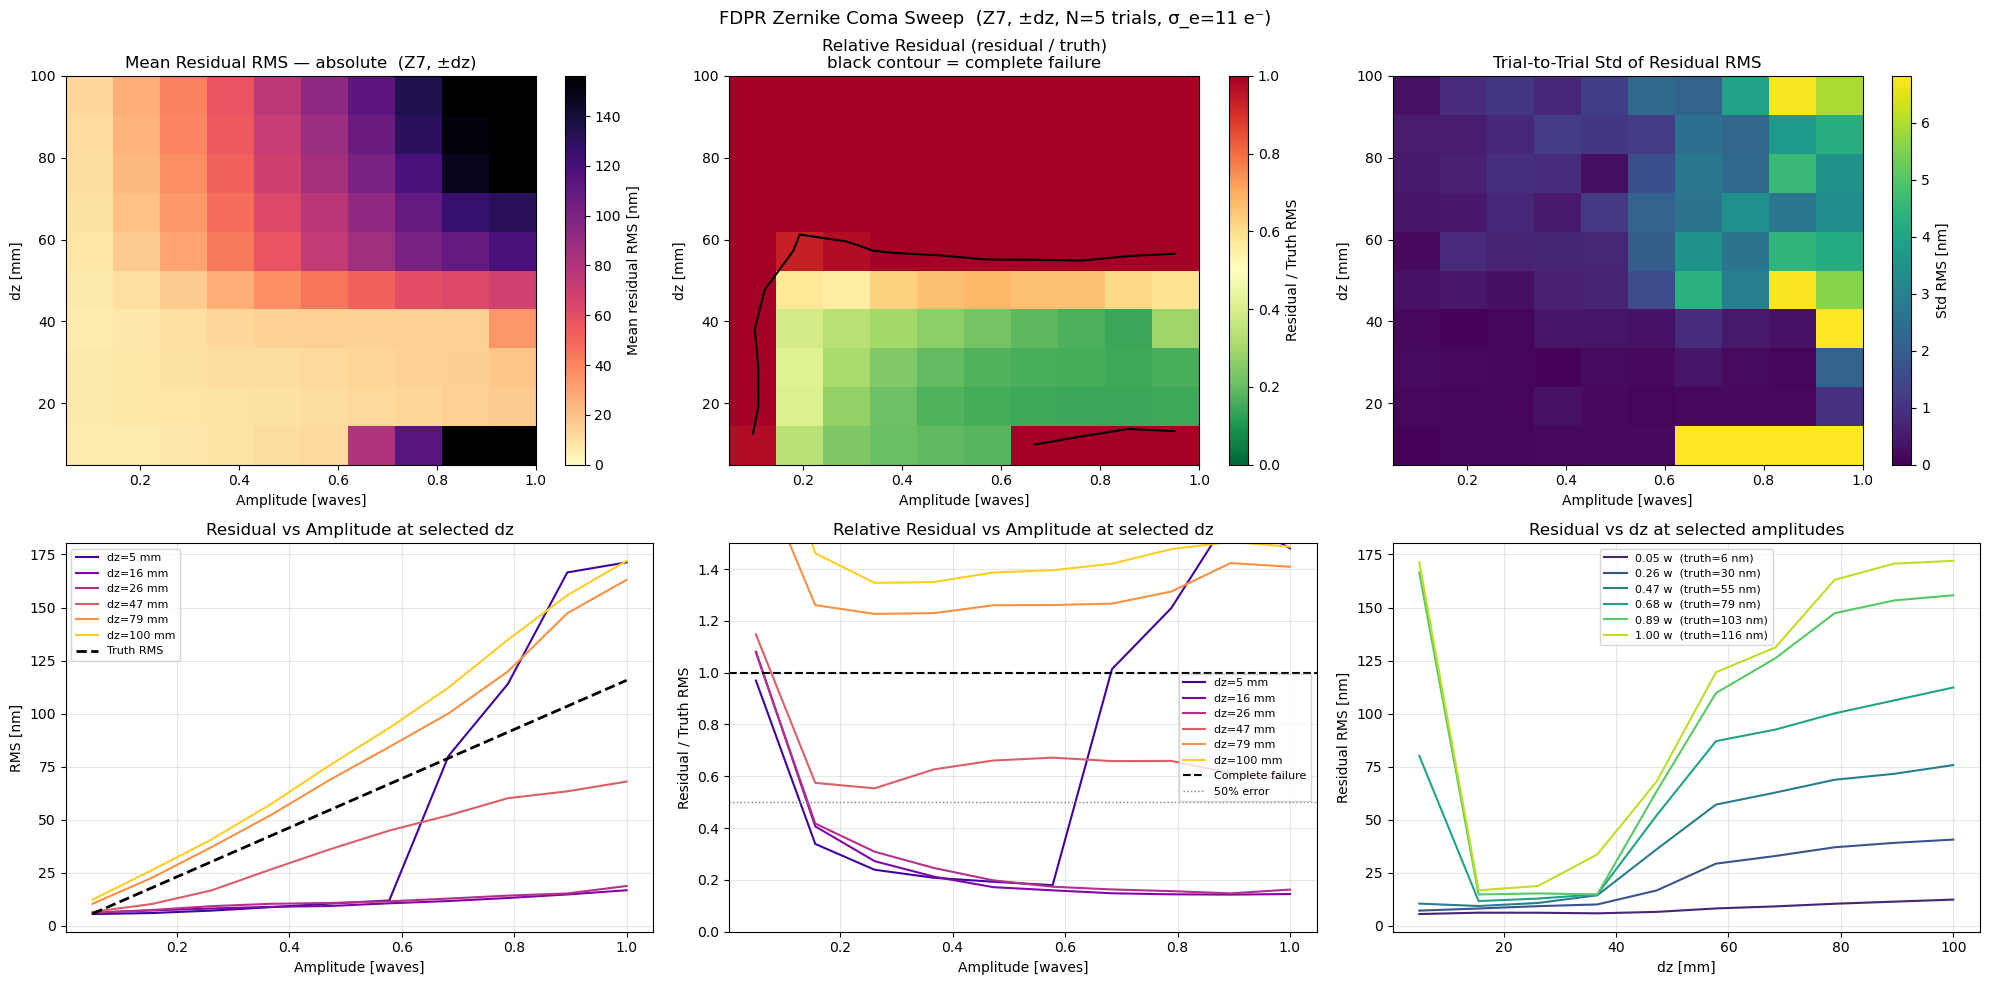

Saved: zernike_sweep_analysis.png

Spot-check: dz=15.6 mm,  amp=0.79 waves,  truth RMS=91.3 nm
Spot-check residual RMS: 13.2 nm  (14% of truth)


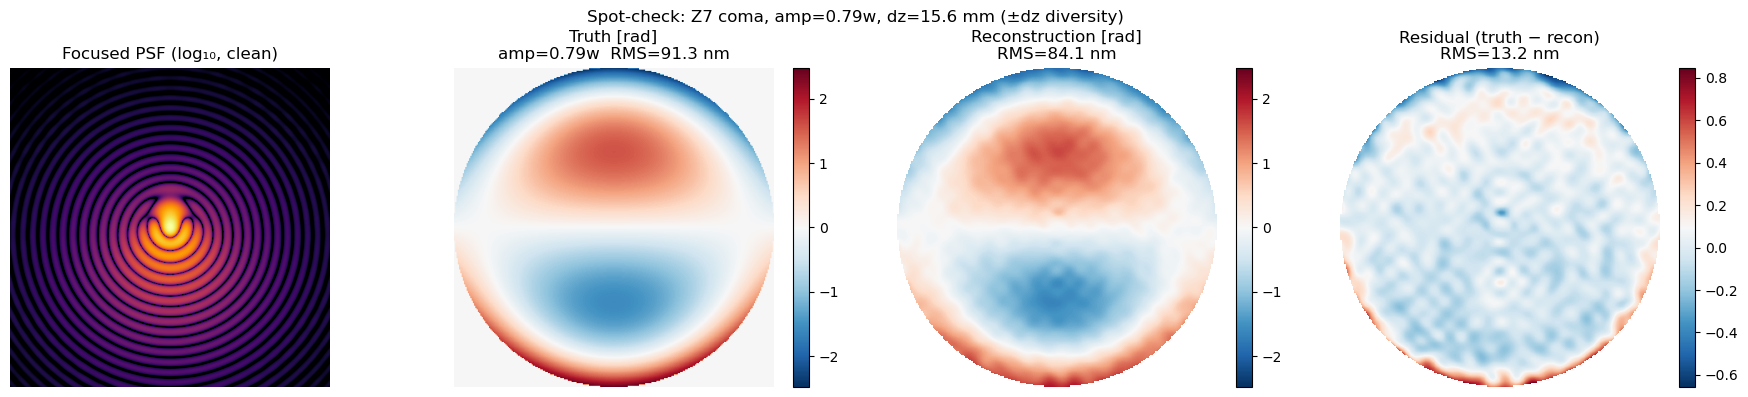

Saved: /Users/joshuapotter/Documents/SEAL/FDPRNotebooks/spotcheck_dz1_amp7.png


In [ ]:
"""
analyze_zernike_sweep.py
========================
Load and analyze fdpr_mc_pm_zernike.npz.
Prints summary stats and produces four plots:
  1. Heatmap of mean residual RMS
  2. Heatmap of std across trials
  3. Residual vs amplitude at selected dz values (with truth RMS overlay)
  4. Residual vs dz at selected amplitudes
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from hcipy import *

# ─────────────────────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────────────────────

import os
HERE = "/Users/joshuapotter/Documents/SEAL/FDPRNotebooks"
FILE = os.path.join(HERE, "fdpr_mc_pm_zernike.npz")
d = np.load(FILE)

dz_grid   = d['dz_grid_mm']       # shape (Ndz,)
amp_grid  = d['param_grid']       # shape (Np,)  — amplitude in waves
rms_mean  = d['rms_mean']         # shape (Ndz, Np)
rms_std   = d['rms_std']          # shape (Ndz, Np)
rms_trials = d['rms_trials']      # shape (Ndz, Np, N_trials)
conv_rate = d['conv_rate']        # shape (Ndz, Np)
mode_idx  = int(d['zernike_mode'])
N_trials  = int(d['N_trials'])
N_iter    = int(d['N_iter'])
sigma_e   = float(d['sigma_e'])

Ndz = len(dz_grid)
Np  = len(amp_grid)

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE TRUTH RMS PER AMPLITUDE
# ─────────────────────────────────────────────────────────────────────────────

seal = {
    'pupil_size':            10.12e-3,
    'pupil_pixel_dimension': 256,
    'wavelength_meter':      650e-9,
}
pupil_grid = make_pupil_grid(seal['pupil_pixel_dimension'], seal['pupil_size'])
tp         = make_circular_aperture(seal['pupil_size'])(pupil_grid)
pm         = np.array(tp.shaped, dtype=bool)
zz         = make_zernike_basis(num_modes=256, D=seal['pupil_size'], grid=pupil_grid)
mode       = zz[mode_idx]
mode_s     = mode.shaped
p2v        = mode_s[pm].max() - mode_s[pm].min()
wvl        = seal['wavelength_meter']

truth_rms = np.array([
    np.sqrt(np.mean(((mode / p2v) * (a * 2 * np.pi)).shaped[pm] ** 2))
    * wvl / (2 * np.pi) * 1e9
    for a in amp_grid
])

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"File         : {FILE}")
print(f"Mode         : Z{mode_idx+1} (index {mode_idx})")
print(f"Grid         : {Ndz} dz × {Np} amplitudes  ({Ndz*Np} points)")
print(f"Trials/point : {N_trials}   Iterations: {N_iter}   σ_e={sigma_e} e⁻")
print(f"dz range     : {dz_grid[0]:.1f} – {dz_grid[-1]:.1f} mm")
print(f"amp range    : {amp_grid[0]:.3f} – {amp_grid[-1]:.3f} waves")
print()

valid = rms_mean[np.isfinite(rms_mean)]
print(f"Residual RMS  mean : {np.mean(valid):.1f} nm")
print(f"              std  : {np.std(valid):.1f} nm")
print(f"              range: {np.min(valid):.1f} – {np.max(valid):.1f} nm")
print()

# Best dz per amplitude column
print("Best dz per amplitude:")
for j, amp in enumerate(amp_grid):
    col = rms_mean[:, j]
    best_i = np.nanargmin(col)
    frac = col[best_i] / truth_rms[j] * 100
    print(f"  amp={amp:.2f}w  truth={truth_rms[j]:.1f} nm  "
          f"best dz={dz_grid[best_i]:.1f} mm  residual={col[best_i]:.1f} nm  ({frac:.0f}% of truth)")

print()
# Best amplitude per dz row
print("Best amplitude per dz:")
for i, dz in enumerate(dz_grid):
    row = rms_mean[i, :]
    best_j = np.nanargmin(row)
    frac = row[best_j] / truth_rms[best_j] * 100
    print(f"  dz={dz:.1f} mm  best amp={amp_grid[best_j]:.2f}w  "
          f"residual={row[best_j]:.1f} nm  ({frac:.0f}% of truth={truth_rms[best_j]:.1f} nm)")

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

extent = [amp_grid[0], amp_grid[-1], dz_grid[0], dz_grid[-1]]
cmap   = 'magma_r'

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# 1. Mean RMS heatmap (absolute)
ax = axes[0, 0]
vmax = np.nanpercentile(rms_mean, 95)
im = ax.imshow(rms_mean, origin='lower', aspect='auto', extent=extent,
               cmap=cmap, vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean residual RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title(f'Mean Residual RMS — absolute  (Z{mode_idx+1}, ±dz)')

# 2. Relative residual heatmap (residual / truth_rms)
ax = axes[0, 1]
rel = rms_mean / truth_rms[np.newaxis, :]   # broadcast truth across dz rows
im2 = ax.imshow(rel, origin='lower', aspect='auto', extent=extent,
                cmap='RdYlGn_r', vmin=0, vmax=1.0)
cb2 = plt.colorbar(im2, ax=ax, label='Residual / Truth RMS')
# Mark the 1.0 contour (residual = truth = complete failure)
ax.contour(rel, levels=[1.0], colors='k', linewidths=1.5,
           extent=extent, origin='lower')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Relative Residual (residual / truth)\nblack contour = complete failure')

# 3. Std heatmap
ax = axes[0, 2]
im3 = ax.imshow(rms_std, origin='lower', aspect='auto', extent=extent,
                cmap='viridis', vmin=0, vmax=np.nanpercentile(rms_std, 95))
plt.colorbar(im3, ax=ax, label='Std RMS [nm]')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('dz [mm]')
ax.set_title('Trial-to-Trial Std of Residual RMS')

# 4. Residual vs amplitude at selected dz
ax = axes[1, 0]
selected_dz_idx = [0, 1, 2, 4, 7, 9]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(selected_dz_idx)))
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx], color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.plot(amp_grid, truth_rms, 'k--', lw=2, label='Truth RMS')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('RMS [nm]')
ax.set_title('Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5. Relative residual vs amplitude at selected dz
ax = axes[1, 1]
for idx, color in zip(selected_dz_idx, colors):
    ax.plot(amp_grid, rms_mean[idx] / truth_rms, color=color,
            label=f'dz={dz_grid[idx]:.0f} mm')
ax.axhline(1.0, color='k', lw=1.5, ls='--', label='Complete failure')
ax.axhline(0.5, color='gray', lw=1, ls=':', label='50% error')
ax.set_xlabel('Amplitude [waves]')
ax.set_ylabel('Residual / Truth RMS')
ax.set_title('Relative Residual vs Amplitude at selected dz')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5)

# 6. Residual vs dz at selected amplitudes
ax = axes[1, 2]
selected_amp_idx = [0, 2, 4, 6, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_amp_idx)))
for jdx, color in zip(selected_amp_idx, colors):
    ax.plot(dz_grid, rms_mean[:, jdx], color=color,
            label=f'{amp_grid[jdx]:.2f} w  (truth={truth_rms[jdx]:.0f} nm)')
ax.set_xlabel('dz [mm]')
ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Residual vs dz at selected amplitudes')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FDPR Zernike Coma Sweep  (Z{mode_idx+1}, ±dz, N={N_trials} trials, σ_e={sigma_e:.0f} e⁻)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(HERE, 'zernike_sweep_analysis.png'), dpi=150)
plt.show()
print("Saved: zernike_sweep_analysis.png")

# ─────────────────────────────────────────────────────────────────────────────
# SPOT-CHECK: re-run FDPR at a chosen (dz, amplitude) and show reconstruction
# ─────────────────────────────────────────────────────────────────────────────
# Change these two indices to inspect any grid point
SPOT_DZ_IDX  = 1    # row index into dz_grid   (1 → dz ≈ 15.6 mm)
SPOT_AMP_IDX = 7    # column index into amp_grid (7 → amp ≈ 0.79 waves)

import sys
sys.path.insert(0, HERE)
from skimage.transform import resize
from image_sharpening import FocusDiversePhaseRetrieval, mft_rev, InstrumentConfiguration
from hcipy import FraunhoferPropagator, make_focal_grid, Wavefront

seal_param_config = {
    'image_dx':   2.0071,
    'efl':        500e-3 * 1e3,
    'wavelength': 650e-9 * 1e6,
    'pupil_size': 10.12e-3 * 1e3,
}
conf      = InstrumentConfiguration(seal_param_config)
prop_p2f  = FraunhoferPropagator(pupil_grid, make_focal_grid(
    q=16, num_airy=16,
    pupil_diameter=10.12e-3,
    focal_length=500e-3,
    reference_wavelength=650e-9,
), 500e-3)

spot_dz  = dz_grid[SPOT_DZ_IDX]
spot_amp = amp_grid[SPOT_AMP_IDX]
spot_truth_rms = truth_rms[SPOT_AMP_IDX]

print(f"\nSpot-check: dz={spot_dz:.1f} mm,  amp={spot_amp:.2f} waves,  truth RMS={spot_truth_rms:.1f} nm")

# Build aberration + defocus
phi_ab  = (mode / p2v) * (spot_amp * 2 * np.pi)
phi_def_s = zz[3].shaped
phi_def_p2v = phi_def_s[pm].max() - phi_def_s[pm].min()
u_def = zz[3] / phi_def_p2v
dz_m  = spot_dz * 1e-3
opd_m = -dz_m / (8.0 * (500e-3 / 10.12e-3) ** 2)
phi_def = u_def * opd_m * 2 * np.pi / 650e-9

def make_wf(ph):
    wf = Wavefront(tp * np.exp(1j * ph), 650e-9)
    wf.total_power = 1e6
    return wf

RNG2 = np.random.default_rng(99)
psf0   = np.asarray(prop_p2f(make_wf(phi_ab)).power.shaped,           dtype=float)
psfd_p = np.asarray(prop_p2f(make_wf(phi_ab + phi_def)).power.shaped, dtype=float)
psfd_n = np.asarray(prop_p2f(make_wf(phi_ab - phi_def)).power.shaped, dtype=float)

def noisy(p): return np.clip(p + RNG2.normal(scale=sigma_e, size=p.shape), 0, None)

mp = FocusDiversePhaseRetrieval(
    [noisy(psf0), noisy(psfd_p), noisy(psfd_n)],
    0.65, [2.0071, 2.0071], [spot_dz * 1e3, -spot_dz * 1e3]
)
for _ in range(N_iter):
    psf_rec = mp.step()

raw   = np.angle(mft_rev(psf_rec, conf))
recon = resize(raw, (256, 256), preserve_range=True) * tp.shaped

rec_ms   = recon[pm] - np.median(recon[pm])
truth_ms = phi_ab.shaped[pm] - np.median(phi_ab.shaped[pm])
residual_map = np.zeros((256, 256))
residual_map[pm] = truth_ms - rec_ms
rms_spot = np.sqrt(np.nanmean((truth_ms - rec_ms) ** 2)) * 650e-9 / (2*np.pi) * 1e9
print(f"Spot-check residual RMS: {rms_spot:.1f} nm  ({rms_spot/spot_truth_rms*100:.0f}% of truth)")

truth_shaped = phi_ab.shaped * tp.shaped
rec_shaped   = recon.copy(); rec_shaped[~pm] = np.nan
phase_vmax   = np.nanmax(np.abs(truth_shaped[pm]))

fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4))

axes2[0].imshow(np.log10(psf0 / psf0.max() + 1e-10), cmap='inferno', vmin=-5)
axes2[0].set_title('Focused PSF (log₁₀, clean)')
axes2[0].axis('off')

im = axes2[1].imshow(truth_shaped, cmap='RdBu_r', vmin=-phase_vmax, vmax=phase_vmax)
axes2[1].set_title(f'Truth [rad]\namp={spot_amp:.2f}w  RMS={spot_truth_rms:.1f} nm')
axes2[1].axis('off')
plt.colorbar(im, ax=axes2[1], fraction=0.046)

rec_plot = recon - np.median(recon[pm])
rec_plot[~pm] = np.nan
im2 = axes2[2].imshow(rec_plot, cmap='RdBu_r', vmin=-phase_vmax, vmax=phase_vmax)
axes2[2].set_title(f'Reconstruction [rad]\nRMS={np.sqrt(np.nanmean(rec_ms**2))*650e-9/(2*np.pi)*1e9:.1f} nm')
axes2[2].axis('off')
plt.colorbar(im2, ax=axes2[2], fraction=0.046)

residual_map[~pm] = np.nan
im3 = axes2[3].imshow(residual_map, cmap='RdBu_r')
axes2[3].set_title(f'Residual (truth − recon)\nRMS={rms_spot:.1f} nm')
axes2[3].axis('off')
plt.colorbar(im3, ax=axes2[3], fraction=0.046)

fig2.suptitle(f'Spot-check: Z{mode_idx+1} coma, amp={spot_amp:.2f}w, dz={spot_dz:.1f} mm (±dz diversity)',
              fontsize=12)
plt.tight_layout()
spot_png = os.path.join(HERE, f'spotcheck_dz{SPOT_DZ_IDX}_amp{SPOT_AMP_IDX}.png')
plt.savefig(spot_png, dpi=150)
plt.show()
print(f"Saved: {spot_png}")